In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Objective

Analyze customer purchasing behavior to identify recurring customer patterns and determine which behaviors can be translated into automated engagement rules.

## 1 - Exploratory Data Analysis

In [2]:
df = pd.read_csv('../data/online_retail.csv')

In [3]:
df.shape

(541909, 8)

In [4]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 66.3 MB


In [7]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df["Description"].fillna("No description")


0          WHITE HANGING HEART T-LIGHT HOLDER
1                         WHITE METAL LANTERN
2              CREAM CUPID HEARTS COAT HANGER
3         KNITTED UNION FLAG HOT WATER BOTTLE
4              RED WOOLLY HOTTIE WHITE HEART.
                         ...                 
541904            PACK OF 20 SPACEBOY NAPKINS
541905           CHILDREN'S APRON DOLLY GIRL 
541906          CHILDRENS CUTLERY DOLLY GIRL 
541907        CHILDRENS CUTLERY CIRCUS PARADE
541908          BAKING SET 9 PIECE RETROSPOT 
Name: Description, Length: 541909, dtype: str

In [10]:
total_number_of_customers = df["CustomerID"].nunique()

In [11]:
total_number_of_orders = df['InvoiceNo'].nunique()

In [12]:
average_number_of_orders_per_customer = total_number_of_orders / total_number_of_customers

In [13]:
median_number_of_orders_per_customer = df.groupby('CustomerID')['InvoiceNo'].nunique().median()

In [14]:
average_order_value = df['UnitPrice'].mean()

In [15]:
purchases_per_customer = df.groupby('CustomerID')['InvoiceNo'].nunique().sort_values()


## 2 - Visualize customer and revenue distributions

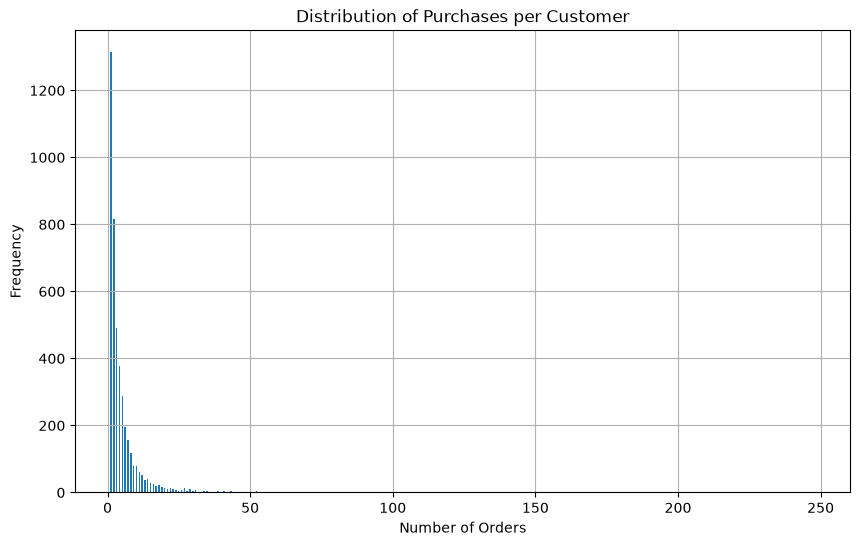

In [16]:
# graph distribution of purchases per customer

plt.figure(figsize=(10, 6))
df.groupby('CustomerID')['InvoiceNo'].nunique().hist(bins=500)
plt.xlabel('Number of Orders')      
plt.ylabel('Frequency')
plt.title('Distribution of Purchases per Customer')
plt.show()

there are a lot of customers that have only one purchase.
- what did they buy
- are they new
- are they a group of their own or are they in the same group as 2-5 purchases

In [17]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

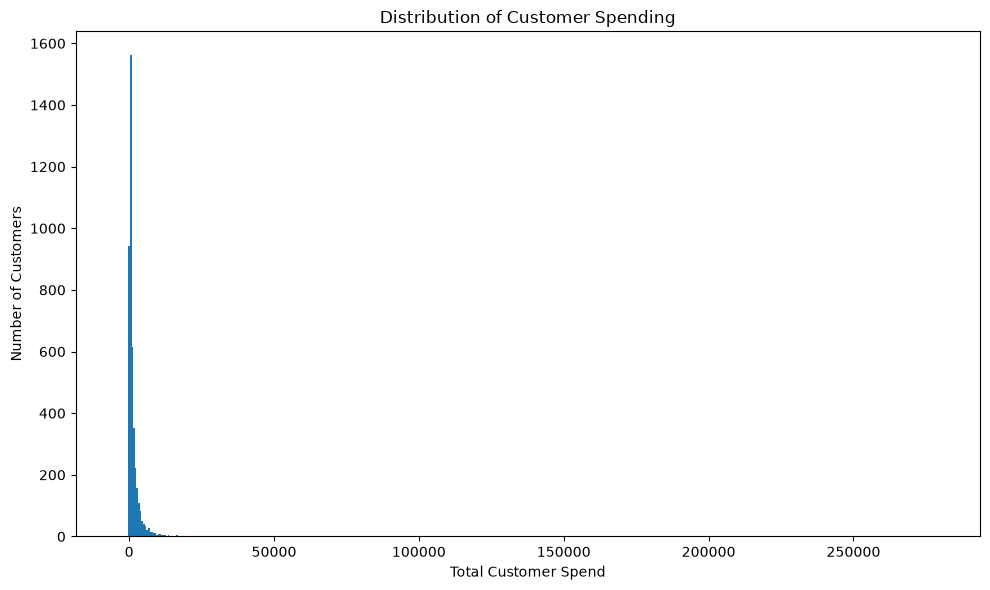

In [18]:
customer_spend = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
)

plt.figure(figsize=(10, 6))

plt.hist(
    customer_spend,
    bins=500
)

plt.title("Distribution of Customer Spending")
plt.xlabel("Total Customer Spend")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

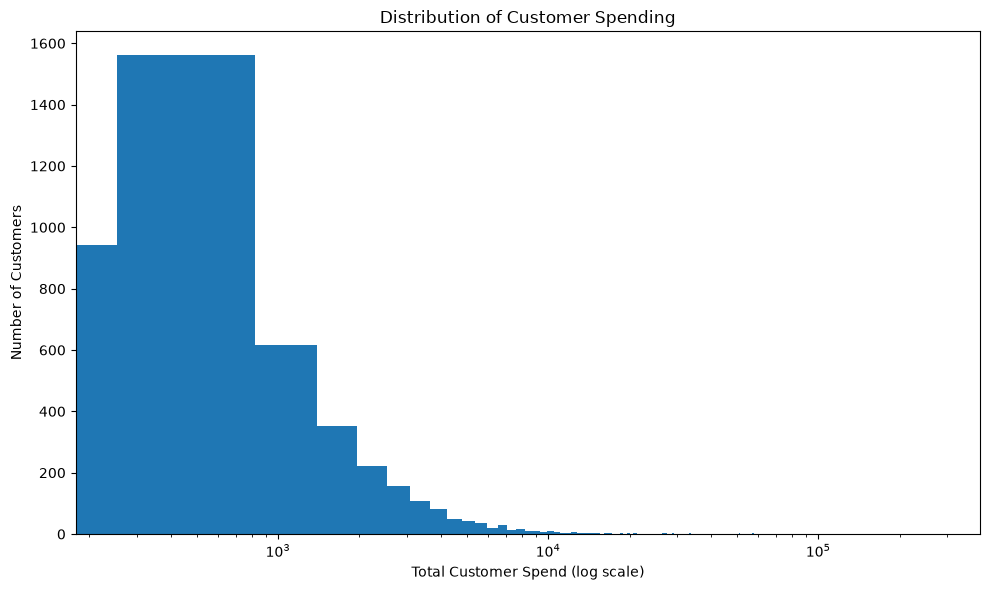

In [19]:
# retail spending is heavily skewed, using a log x-axis
plt.figure(figsize=(10, 6))

plt.hist(
    customer_spend,
    bins=500
)

plt.xscale("log")

plt.title("Distribution of Customer Spending")
plt.xlabel("Total Customer Spend (log scale)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

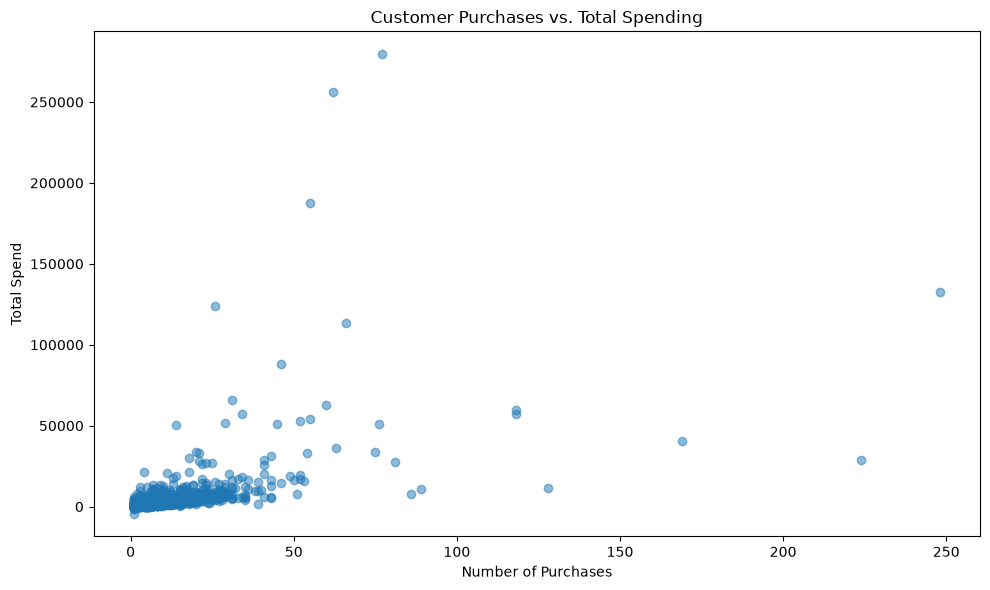

In [20]:
customer_summary = (
    df.groupby("CustomerID")
    .agg(
        Purchases=("InvoiceNo", "nunique"),
        Total_Spend=("Revenue", "sum")
    )
)

plt.figure(figsize=(10, 6))

plt.scatter(
    customer_summary["Purchases"],
    customer_summary["Total_Spend"],
    alpha=0.5
)

plt.title("Customer Purchases vs. Total Spending")
plt.xlabel("Number of Purchases")
plt.ylabel("Total Spend")

plt.tight_layout()
plt.show()

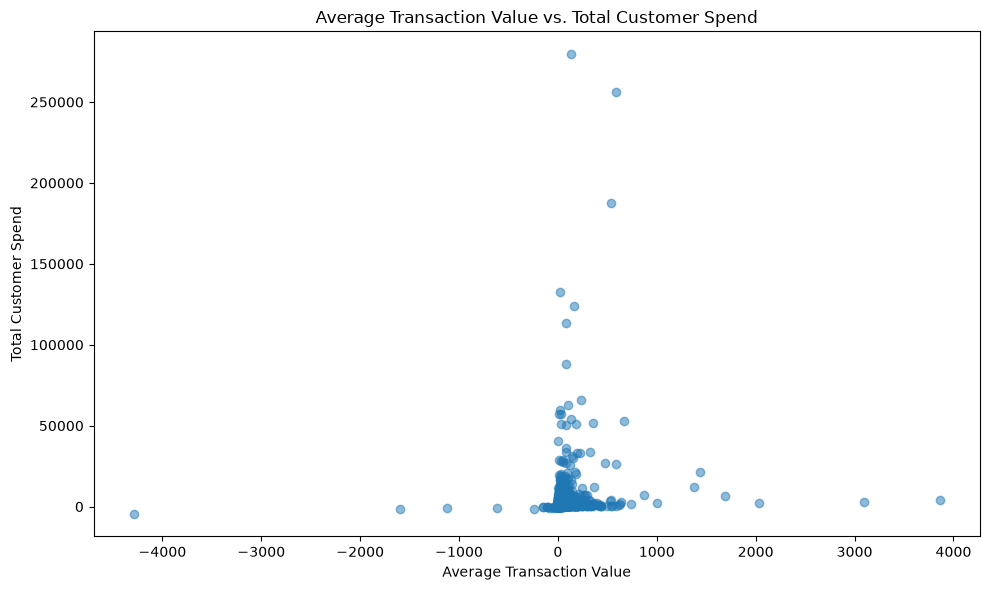

In [21]:
customer_summary = (
    df.groupby("CustomerID")
    .agg(
        Purchases=("InvoiceNo", "nunique"),
        Total_Spend=("Revenue", "sum"),
        Avg_Transaction=("Revenue", "mean")
    )
)

plt.figure(figsize=(10, 6))

plt.scatter(
    customer_summary["Avg_Transaction"],
    customer_summary["Total_Spend"],
    alpha=0.5
)

plt.title("Average Transaction Value vs. Total Customer Spend")
plt.xlabel("Average Transaction Value")
plt.ylabel("Total Customer Spend")

plt.tight_layout()
plt.show()

## 3 - Looking for behavioral dimensions

In [22]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

if not pd.api.types.is_string_dtype(df["CustomerID"]):
    df["CustomerID"] = df["CustomerID"].fillna(0).astype(int).astype(str)

/var/folders/53/vr8gs__x60sg207tybh25bv80000gn/T/ipykernel_59408/2789585944.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])


In [23]:
customer_summary = (
    df.groupby("CustomerID")
    .agg(
        Purchases=("InvoiceNo", "nunique"),
        Total_Spend=("Revenue", "sum"),
        Avg_Transaction=("Revenue", "mean")
    )
)

customer_summary.head(20)


,Purchases,Total_Spend,Avg_Transaction
CustomerID,,,
0,3710,1447682.12,10.717220
12346,2,0.00,0.000000
12347,7,4310.00,23.681319
12348,4,1797.24,57.975484
12349,1,1757.55,24.076027
12350,1,334.40,19.670588
12352,11,1545.41,16.267474
12353,1,89.00,22.250000
12354,1,1079.40,18.610345


#### Group with no customer ID

In [24]:
no_id = df[df["CustomerID"] == "0"].copy()

no_id[
    [
        "InvoiceNo",
        "InvoiceDate",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "Revenue",
        "Country"
    ]
].head(2)

,InvoiceNo,InvoiceDate,StockCode,Description,Quantity,UnitPrice,Revenue,Country
622,536414,2010-12-01 11:52:00,22139,NaN,56,0.00,0.00,United Kingdom
1443,536544,2010-12-01 14:32:00,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2.51,2.51,United Kingdom


In [25]:
no_id[
    ["Quantity", "UnitPrice", "Revenue"]
].describe()

,Quantity,UnitPrice,Revenue
count,135080.000000,135080.000000,135080.000000
mean,1.995573,8.076577,10.717220
std,66.696153,151.900816,157.967893
min,-9600.000000,-11062.060000,-17836.460000
25%,1.000000,1.630000,2.460000
50%,1.000000,3.290000,4.960000
75%,3.000000,5.450000,10.790000
max,5568.000000,17836.460000,13541.330000


In [26]:
no_id["Revenue"].sum()

np.float64(1447682.12)

In [27]:
no_id["InvoiceDate"].agg(["min", "max"])

min   2010-12-01 11:52:00
max   2011-12-09 10:26:00
Name: InvoiceDate, dtype: datetime64[us]

In [28]:
no_ID_products = (
    no_id
    .groupby("Description")
    .agg(
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum"),
        Transactions=("InvoiceNo", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

no_ID_products.head(20)

,Units,Revenue,Transactions
Description,,,
DOTCOM POSTAGE,691,194339.12,693
REGENCY CAKESTAND 3 TIER,1478,31891.79,285
PARTY BUNTING,2995,30615.45,307
PAPER CHAIN KIT 50'S CHRISTMAS,3738,22291.46,180
CHARLOTTE BAG SUKI DESIGN,9177,22139.30,297
HOT WATER BOTTLE TEA AND SYMPATHY,1964,17407.37,130
RABBIT NIGHT LIGHT,3586,15618.79,193
RED RETROSPOT CHARLOTTE BAG,4962,11650.94,295
POPCORN HOLDER,5830,10871.16,171


In [29]:
no_id["Month"] = no_id["InvoiceDate"].dt.to_period("M")

no_id_monthly = (
    no_id
    .groupby("Month")
    .agg(
        Transactions=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
)

no_id_monthly

,Transactions,Units,Revenue
Month,,,
2010-12,317,45866,194353.00
2011-01,240,39587,84925.88
2011-02,191,15156,61516.50
2011-03,364,7860,103302.47
2011-04,360,10513,67159.27
2011-05,313,12539,75082.43
2011-06,305,-15299,83109.96
2011-07,334,27698,107061.63
2011-08,193,19587,66312.51


In [30]:

print("Earliest time:", no_id["InvoiceDate"].dt.time.min())
print("Latest time:", no_id["InvoiceDate"].dt.time.max())


Earliest time: 08:20:00
Latest time: 19:49:00


In [31]:
no_id["Hour"] = no_id["InvoiceDate"].dt.hour

hourly_volume = (
    no_id
    .groupby("Hour")
    .agg(
        Transactions=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
)

hourly_volume

,Transactions,Units,Revenue
Hour,,,
8,16,853,1737.59
9,202,33357,111619.22
10,348,-2490,178499.56
11,395,8578,92799.01
12,365,8242,25392.52
13,326,11655,54830.94
14,492,33980,146609.08
15,664,66300,290499.42
16,461,66703,281749.93


In [32]:
no_id["Day"] = no_id["InvoiceDate"].dt.day_name()


day_volume = (
    no_id
    .groupby("Day")
    .agg(
        Transactions=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
)


In [33]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_volume = day_volume.reindex(day_order)

day_volume

,Transactions,Units,Revenue
Day,,,
Monday,626.0,73668.0,314057.92
Tuesday,830.0,49055.0,402989.20
Wednesday,705.0,28983.0,203669.52
Thursday,682.0,49941.0,206410.81
Friday,828.0,63397.0,299294.63
Saturday,NaN,NaN,NaN
Sunday,39.0,4518.0,21260.04


In [34]:
day_dates = (
    no_id
    .assign(Day=no_id["InvoiceDate"].dt.day_name())
    .groupby("Day")["InvoiceDate"]
    .apply(lambda x: x.dt.date.nunique())
    .reindex(day_order, fill_value=0)
)

day_dates

Day
Monday       47
Tuesday      52
Wednesday    53
Thursday     53
Friday       50
Saturday      0
Sunday       22
Name: InvoiceDate, dtype: int64

In [35]:
day_volume["Transaction_Pct"] = (
    day_volume["Transactions"] /
    day_volume["Transactions"].sum() * 100
)

day_volume

,Transactions,Units,Revenue,Transaction_Pct
Day,,,,
Monday,626.0,73668.0,314057.92,16.873315
Tuesday,830.0,49055.0,402989.20,22.371968
Wednesday,705.0,28983.0,203669.52,19.002695
Thursday,682.0,49941.0,206410.81,18.382749
Friday,828.0,63397.0,299294.63,22.318059
Saturday,NaN,NaN,NaN,NaN
Sunday,39.0,4518.0,21260.04,1.051213


The no_id transactions appear to represent a distinct group within the dataset and may represent direct or end-user sales rather than purchases from identified reseller customers. This is a working hypothesis based on the purchasing patterns in the data, not something the dataset specifically identifies.

The no_id transactions occur mostly during the workweek, with sales recorded Monday through Friday and a smaller number on Sundays. Tuesday and Friday have the highest transaction volumes, but there isn't one day that stands out as dramatically busier than the others.

This is interesting because if these sales were primarily coming from something like a farmers market, makers market, pop-up event, or another periodic retail operation, I would expect to see much larger spikes on particular days. That pattern isn't really present in the data. Instead, the sales are spread across a number of weekdays, which makes a regular event-based sales channel less obvious.

The next step is to compare no_id and identified customers by revenue, units sold, product mix, transaction size, and timing. That should help determine whether these two groups are actually behaving like different types of sales channels.

#### Stock codes without descriptions

In [36]:
no_description = df[df["Description"].isna()].copy()

print("Rows with no description:", len(no_description))
print("Unique StockCodes:", no_description["StockCode"].nunique())

print("\nStockCodes:")
print(no_description["StockCode"].unique())

print("\nPrice range:")
print("Lowest price:", no_description["UnitPrice"].min())
print("Highest price:", no_description["UnitPrice"].max())

Rows with no description: 1454
Unique StockCodes: 960

StockCodes:
<ArrowStringArray>
[ '22139',  '21134',  '22145',  '37509', '85226A',  '85044',  '20950',
  '37461',  '84670',  '21777',
 ...
  '22947',  '22696',  '21758',  '21808',  '21803',  '22689',  '84581',
  '23406',  '21620',  '85175']
Length: 960, dtype: str

Price range:
Lowest price: 0.0
Highest price: 0.0


In [37]:
no_description = df[df["Description"].isna()].copy()

missing_description_summary = (
    no_description
    .groupby("StockCode")
    .agg(
        Rows=("StockCode", "size"),
        Transactions=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Customers=("CustomerID", "nunique"),
        Countries=("Country", "nunique")
    )
    .sort_values("Transactions", ascending=False)
)

missing_description_summary

,Rows,Transactions,Units,Customers,Countries
StockCode,,,,,
35965,10,10,38,1,1
23084,10,10,332,1,1
22084,9,9,-129,1,1
22451,6,6,-14,1,1
23348,5,5,794,1,1
...,...,...,...,...,...
22453,1,1,-12,1,1
22454,1,1,-20,1,1
22461,1,1,-36,1,1


In [38]:
invoice_item_counts = (
    df.groupby("InvoiceNo")["StockCode"]
    .nunique()
    .rename("Unique_Items")
)

no_description_orders = no_description.copy()

no_description_orders = no_description_orders.merge(
    invoice_item_counts,
    on="InvoiceNo",
    how="left"
)

no_description_orders["Order_Type"] = np.where(
    no_description_orders["Unique_Items"] == 1,
    "Stand-alone",
    "Multiple items"
)

In [39]:
order_type_summary = (
    no_description_orders
    .groupby(["StockCode", "Order_Type"])
    .agg(
        Orders=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum")
    )
    .reset_index()
)

order_type_summary

,StockCode,Order_Type,Orders,Units
0,10002,Stand-alone,2,177
1,10080,Stand-alone,1,170
2,10123C,Stand-alone,1,-18
3,10123G,Stand-alone,1,-38
4,10134,Stand-alone,1,-19
...,...,...,...,...
955,DCGS0074,Stand-alone,1,-1
956,DOT,Stand-alone,1,1000
957,POST,Stand-alone,4,3350
958,gift_0001_10,Stand-alone,1,30


In [40]:
no_description_orders["Customer_Type"] = np.where(
    no_description_orders["CustomerID"] == 0,
    "no_id",
    "Identified"
)

customer_type_summary = (
    no_description_orders
    .groupby(["StockCode", "Customer_Type"])
    .agg(
        Orders=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum")
    )
    .reset_index()
)

customer_type_summary

,StockCode,Customer_Type,Orders,Units
0,10002,Identified,2,177
1,10080,Identified,1,170
2,10123C,Identified,1,-18
3,10123G,Identified,1,-38
4,10134,Identified,1,-19
...,...,...,...,...
955,DCGS0074,Identified,1,-1
956,DOT,Identified,1,1000
957,POST,Identified,4,3350
958,gift_0001_10,Identified,1,30


In [41]:
alpha_stock_codes = (
    no_description.loc[
        no_description["StockCode"].str.contains(r"[A-Za-z]", na=False),
        "StockCode"
    ]
    .drop_duplicates()
    .sort_values()
)

alpha_stock_codes.tolist()

['10123C',
 '10123G',
 '15044B',
 '15058A',
 '15058B',
 '15060B',
 '16020C',
 '16151A',
 '16156S',
 '16162L',
 '16162M',
 '16169K',
 '16169P',
 '16202B',
 '16207A',
 '16207B',
 '16244B',
 '16248B',
 '17007B',
 '17011A',
 '17011F',
 '17012A',
 '17012B',
 '17013D',
 '17014A',
 '17090D',
 '17091A',
 '17165D',
 '18094C',
 '18097A',
 '18098C',
 '35001W',
 '35004C',
 '35004P',
 '35271S',
 '35591T',
 '35592T',
 '35597A',
 '35597D',
 '35598A',
 '35603B',
 '35607A',
 '35609A',
 '35809A',
 '35809B',
 '35810B',
 '35815P',
 '35818B',
 '35819B',
 '35819P',
 '35823P',
 '35824B',
 '35911A',
 '35915C',
 '35916A',
 '35916B',
 '35916C',
 '37379A',
 '37444A',
 '37444B',
 '37444C',
 '37477B',
 '37477C',
 '37477D',
 '37479B',
 '37489A',
 '40018F',
 '40046A',
 '44091A',
 '46037A',
 '46115B',
 '46126A',
 '46775D',
 '47013C',
 '47021G',
 '47341A',
 '47343A',
 '47344B',
 '47503A',
 '47504K',
 '47556B',
 '47559B',
 '47563B',
 '47570B',
 '47574B',
 '47591A',
 '47591B',
 '47591D',
 '47593A',
 '48173C',
 '62043B',

#### Looking into ALPHA codes

In [42]:
codes_to_check = [
    "C2",
    "DCGS0055",
    "DCGS0057",
    "DCGS0066P",
    "DCGS0070",
    "DCGS0071",
    "DCGS0072",
    "DCGS0074",
    "DOT",
    "POST",
    "gift_0001_10",
    "gift_0001_30"
]

code_details = (
    df[df["StockCode"].isin(codes_to_check)]
    .groupby("StockCode")
    .agg(
        Rows=("StockCode", "size"),
        Orders=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum"),
        Customers=("CustomerID", "nunique"),
        Avg_Price=("UnitPrice", "mean"),
        Min_Price=("UnitPrice", "min"),
        Max_Price=("UnitPrice", "max")
    )
    .sort_values("Orders", ascending=False)
)

code_details

,Rows,Orders,Units,Revenue,Customers,Avg_Price,Min_Price,Max_Price
StockCode,,,,,,,,
POST,1256,1254,6353,66230.64,380,36.933495,0.0,8142.75
DOT,710,710,1707,206245.48,2,290.495859,0.0,4505.17
C2,144,144,290,6986.00,30,49.291667,0.0,150.00
gift_0001_10,9,9,39,74.97,1,7.404444,0.0,8.33
gift_0001_30,8,8,37,175.53,1,21.941250,0.0,25.53
DCGS0070,2,2,-7,12.72,1,6.360000,0.0,12.72
DCGS0055,1,1,-1,0.00,1,0.000000,0.0,0.00
DCGS0057,1,1,-6,0.00,1,0.000000,0.0,0.00
DCGS0066P,1,1,-3,0.00,1,0.000000,0.0,0.00


In [43]:
customer_type = (
    df[df["StockCode"].isin(codes_to_check)]
    .assign(
        Customer_Type=lambda x: np.where(
            x["CustomerID"] == 0,
            "no_id",
            "Identified"
        )
    )
    .groupby(["StockCode", "Customer_Type"])
    .agg(
        Orders=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

customer_type

,StockCode,Customer_Type,Orders,Units,Revenue
0,C2,Identified,144,290,6986.00
1,DCGS0055,Identified,1,-1,0.00
2,DCGS0057,Identified,1,-6,0.00
3,DCGS0066P,Identified,1,-3,0.00
4,DCGS0070,Identified,2,-7,12.72
5,DCGS0071,Identified,1,-2,0.00
6,DCGS0072,Identified,1,-1,0.00
7,DCGS0074,Identified,1,-1,0.00
8,DOT,Identified,710,1707,206245.48
9,POST,Identified,1254,6353,66230.64


In [44]:
invoice_items = (
    df.groupby("InvoiceNo")["StockCode"]
    .nunique()
    .rename("Unique_Items")
)

code_orders = (
    df[df["StockCode"].isin(codes_to_check)]
    .merge(invoice_items, on="InvoiceNo")
    .assign(
        Order_Type=lambda x: np.where(
            x["Unique_Items"] == 1,
            "Stand-alone",
            "Multiple items"
        )
    )
    .groupby(["StockCode", "Order_Type"])
    .agg(
        Orders=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum")
    )
    .reset_index()
)

code_orders

,StockCode,Order_Type,Orders,Units
0,C2,Multiple items,140,137
1,C2,Stand-alone,4,153
2,DCGS0055,Stand-alone,1,-1
3,DCGS0057,Stand-alone,1,-6
4,DCGS0066P,Stand-alone,1,-3
5,DCGS0070,Multiple items,1,1
6,DCGS0070,Stand-alone,1,-8
7,DCGS0071,Stand-alone,1,-2
8,DCGS0072,Stand-alone,1,-1
9,DCGS0074,Stand-alone,1,-1


In [45]:
# pd.set_option("display.max_rows", None)


In [46]:
codes_to_check = [
    "C2",
    "DCGS0055",
    "DCGS0057",
    "DCGS0066P",
    "DCGS0070",
    "DCGS0071",
    "DCGS0072",
    "DCGS0074"
]

df[df["StockCode"].isin(codes_to_check)][
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "CustomerID",
        "Country",
        "InvoiceDate"
    ]
].sort_values(["StockCode", "InvoiceDate"])

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,InvoiceDate
1423,536540,C2,CARRIAGE,1,50.00,14911,EIRE,2010-12-01 14:05:00
12119,537368,C2,CARRIAGE,1,50.00,14911,EIRE,2010-12-06 12:40:00
12452,537378,C2,CARRIAGE,1,50.00,14911,EIRE,2010-12-06 13:06:00
19975,537963,C2,CARRIAGE,1,50.00,13369,United Kingdom,2010-12-09 11:30:00
20016,538002,C2,CARRIAGE,1,50.00,14932,Channel Islands,2010-12-09 11:48:00
...,...,...,...,...,...,...,...,...
40052,539718,DCGS0070,CAMOUFLAGE DOG COLLAR,1,12.72,0,United Kingdom,2010-12-21 13:06:00
279253,561251,DCGS0070,NaN,-8,0.00,0,United Kingdom,2011-07-26 11:51:00
279252,561250,DCGS0071,NaN,-2,0.00,0,United Kingdom,2011-07-26 11:51:00
74838,542531,DCGS0072,NaN,-1,0.00,0,United Kingdom,2011-01-28 13:08:00


In [47]:
dcgs = df[df["StockCode"].str.startswith("DCGS", na=False)].copy()

dcgs.groupby("StockCode").agg(
    Rows=("StockCode", "size"),
    Descriptions=("Description", lambda x: x.dropna().unique().tolist()),
    Units=("Quantity", "sum"),
    Min_Price=("UnitPrice", "min"),
    Max_Price=("UnitPrice", "max"),
    Orders=("InvoiceNo", "nunique"),
    Customers=("CustomerID", "nunique")
)

,Rows,Descriptions,Units,Min_Price,Max_Price,Orders,Customers
StockCode,,,,,,,
DCGS0003,5,"[BOXED GLASS ASHTRAY, ebay]",-3,0.00,2.51,5,1
DCGS0004,1,[HAYNES CAMPER SHOULDER BAG],1,16.63,16.63,1,1
DCGS0055,1,[],-1,0.00,0.00,1,1
DCGS0057,1,[],-6,0.00,0.00,1,1
DCGS0066P,1,[],-3,0.00,0.00,1,1
DCGS0067,1,[ebay],-11,0.00,0.00,1,1
DCGS0068,1,[ebay],-10,0.00,0.00,1,1
DCGS0069,2,"[OOH LA LA DOGS COLLAR, ebay]",-4,0.00,15.79,2,1
DCGS0070,2,[CAMOUFLAGE DOG COLLAR],-7,0.00,12.72,2,1


In [48]:
dcgs[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "CustomerID",
        "Country",
        "InvoiceDate"
    ]
].sort_values(["StockCode", "InvoiceDate"])

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,InvoiceDate
24906,538349,DCGS0003,BOXED GLASS ASHTRAY,1,2.51,0,United Kingdom,2010-12-10 14:59:00
36460,539451,DCGS0003,BOXED GLASS ASHTRAY,1,2.51,0,United Kingdom,2010-12-17 16:59:00
76251,542622,DCGS0003,BOXED GLASS ASHTRAY,1,2.46,0,United Kingdom,2011-01-31 09:09:00
176006,551995,DCGS0003,BOXED GLASS ASHTRAY,1,2.46,0,United Kingdom,2011-05-05 15:42:00
279258,561256,DCGS0003,ebay,-7,0.00,0,United Kingdom,2011-07-26 11:53:00
170783,551340,DCGS0004,HAYNES CAMPER SHOULDER BAG,1,16.63,0,United Kingdom,2011-04-27 17:23:00
74825,542529,DCGS0055,NaN,-1,0.00,0,United Kingdom,2011-01-28 13:08:00
75295,542582,DCGS0057,NaN,-6,0.00,0,United Kingdom,2011-01-28 15:01:00
279257,561255,DCGS0066P,NaN,-3,0.00,0,United Kingdom,2011-07-26 11:52:00
279256,561254,DCGS0067,ebay,-11,0.00,0,United Kingdom,2011-07-26 11:52:00


Further investigation of the transactions with missing product descriptions found that the missing descriptions are not limited to a single type of transaction. The `C2` stock code is a good example: most `C2` records are described as **CARRIAGE**, while the records with a missing description have the same general characteristics. The price is consistently 50, with the exception of one end-user transaction. This suggests that the missing description for `C2` is likely a missing label for a carriage-related charge rather than an unidentified product.

The `DCGS` stock codes were more varied. Some clearly correspond to products, including a HAYNES CAMPER SHOULDER BAG, CAMOUFLAGE DOG COLLAR, SUNJAR LED NIGHT NIGHT LIGHT, BOYS PARTY BAG, and GIRLS PARTY BAG. Other codes are associated with `ebay`, while several of the codes with missing descriptions have a quantity of zero-priced negative units. These records appear more consistent with returns, adjustments, or other inventory corrections than normal product sales. Overall, the missing descriptions do not appear to represent one consistent category of transaction. Some are likely legitimate products with incomplete descriptions, while others appear to be charges, eBay-related transactions, or adjustments. For that reason, the records should not simply be removed from the dataset; instead, they should be considered separately when analyzing product sales and customer purchasing behavior.


#### Looking into the customers with ID 

In [49]:
identified = df[df["CustomerID"] != "0"].copy()

customer_summary = (
    identified
    .groupby("CustomerID")
    .agg(
        Purchases=("InvoiceNo", "nunique"),
        Total_Spend=("Revenue", "sum"),
        Avg_Transaction=("Revenue", "mean"),
        Unique_Products=("StockCode", "nunique"),
    )
)

# (identified["CustomerID"] == 0).sum()
(customer_summary.index == "0").sum()

np.int64(0)

In [50]:
customer_purchases = (
    identified
    .groupby(["CustomerID", "InvoiceNo"])["InvoiceDate"]
    .min()
    .reset_index()
    .sort_values(["CustomerID", "InvoiceDate"])
)
customer_purchases["Days_Between"] = (
    customer_purchases
    .groupby("CustomerID")["InvoiceDate"]
    .diff()
    .dt.total_seconds()
    .div(86400)
)
# (customer_purchases["CustomerID"] == "0").sum()
(customer_purchases["CustomerID"] == 0).sum()

np.int64(0)

In [51]:
purchase_timing = (
    customer_purchases
    .groupby("CustomerID")
    .agg(
        Avg_Days_Between=("Days_Between", "mean"),
        Variation_Days_Between=("Days_Between", "std")
    )
)
customer_summary = customer_summary.join(purchase_timing)



In [52]:
customer_summary.describe().T

,count,mean,std,min,25%,50%,75%,max
Purchases,4372.0,5.075480,9.338754,1.00,1.000000,3.000000,5.000000,248.000000
Total_Spend,4372.0,1898.459701,8219.345141,-4287.63,293.362500,648.075000,1611.725000,279489.020000
Avg_Transaction,4372.0,28.839013,127.323926,-4287.63,10.985960,16.918616,23.542941,3861.000000
Unique_Products,4372.0,61.211116,85.425119,1.00,15.000000,35.000000,77.000000,1794.000000
Avg_Days_Between,3059.0,60.637396,61.765206,0.00,21.109549,41.555417,76.036285,365.981944
Variation_Days_Between,2242.0,43.416895,37.675545,0.00,18.085442,32.615079,55.970387,253.249312


In [53]:
customer_summary[
    [
        "Purchases",
        "Avg_Days_Between",
        "Total_Spend",
        "Avg_Transaction",
        "Unique_Products",
        "Variation_Days_Between"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Purchases,4372.0,5.075480,9.338754,1.00,1.000000,3.000000,5.000000,248.000000
Avg_Days_Between,3059.0,60.637396,61.765206,0.00,21.109549,41.555417,76.036285,365.981944
Total_Spend,4372.0,1898.459701,8219.345141,-4287.63,293.362500,648.075000,1611.725000,279489.020000
Avg_Transaction,4372.0,28.839013,127.323926,-4287.63,10.985960,16.918616,23.542941,3861.000000
Unique_Products,4372.0,61.211116,85.425119,1.00,15.000000,35.000000,77.000000,1794.000000
Variation_Days_Between,2242.0,43.416895,37.675545,0.00,18.085442,32.615079,55.970387,253.249312


In [54]:
customer_summary[

    [
        "Purchases",
        "Total_Spend",
        "Unique_Products"
    ]
].quantile([0.90, 0.95, 0.99])

,Purchases,Total_Spend,Unique_Products
0.90,11.0,3505.6000,142.00
0.95,16.0,5625.0040,202.35
0.99,36.0,17226.2949,354.00


#### Look into "corporate level buying

In [55]:
corporate_candidates = customer_summary[
    (
        (customer_summary["Purchases"] >= 16).astype(int)
        + (customer_summary["Total_Spend"] >= 5625.004).astype(int)
        + (customer_summary["Unique_Products"] >= 202.35).astype(int)
    ) >= 2
].copy()


In [56]:
len(corporate_candidates)

195

In [57]:
"0" in customer_summary.index

False

In [58]:
len(corporate_candidates) / len(customer_summary) * 100

4.460201280878317

In [59]:
corporate_candidates[
    [
        "Purchases",
        "Total_Spend",
        "Avg_Transaction",
        "Unique_Products",
        "Avg_Days_Between",
        "Variation_Days_Between"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Purchases,195.0,31.866667,30.019112,6.000000,18.000000,24.000000,34.000000,248.000000
Total_Spend,195.0,18866.686410,34254.550841,1296.440000,6325.760000,8574.110000,15417.560000,279489.020000
Avg_Transaction,195.0,55.037644,99.656348,2.771005,13.605313,23.034478,50.159282,667.732152
Unique_Products,195.0,253.953846,239.648460,9.000000,115.000000,226.000000,297.000000,1794.000000
Avg_Days_Between,195.0,16.527045,10.705486,1.506379,10.036210,14.531472,19.495154,64.788611
Variation_Days_Between,195.0,16.284527,11.618986,2.111138,9.527646,13.629063,18.524457,105.804256


In [60]:
other_customers = customer_summary[
    ~customer_summary.index.isin(corporate_candidates.index)
].copy()

In [61]:
comparison = pd.DataFrame({
    "High_Volume": corporate_candidates[
        [
            "Purchases",
            "Total_Spend",
            "Avg_Transaction",
            "Unique_Products",
            "Avg_Days_Between",
            "Variation_Days_Between"
        ]
    ].median(),
    "Other_Customers": other_customers[
        [
            "Purchases",
            "Total_Spend",
            "Avg_Transaction",
            "Unique_Products",
            "Avg_Days_Between",
            "Variation_Days_Between"
        ]
    ].median()
})

comparison

,High_Volume,Other_Customers
Purchases,24.000000,2.000000
Total_Spend,8574.110000,609.850000
Avg_Transaction,23.034478,16.796250
Unique_Products,226.000000,33.000000
Avg_Days_Between,14.531472,44.722321
Variation_Days_Between,13.629063,35.328823


High-volume customers showed substantially more frequent and diverse purchasing behavior than other customers. The median high-volume customer made 24 purchases compared with 2 for other customers and spent $8,574 compared with $610. They also purchased a much wider range of products, with 226 unique products compared with 33. Their average time between purchases was considerably shorter at 14.5 days versus 44.7 days, while the lower variation in purchase intervals (13.6 days versus 35.3 days) suggests their purchasing was also more consistent. Average transaction value was only moderately higher ($23.03 versus $16.80), indicating that the difference in customer value was driven primarily by how frequently and broadly customers purchased rather than by substantially larger individual transactions.

#### Testing the 20/80 rule

In [62]:
customer_count = len(customer_summary)

top_20_count = round(customer_count * 0.20)

top_20_customers = (
    customer_summary
    .sort_values("Total_Spend", ascending=False)
    .head(top_20_count)
    .copy()
)

len(top_20_customers)

874

In [63]:
other_80_customers = (
    customer_summary
    .drop(top_20_customers.index)
    .copy()
)

len(other_80_customers)

3498

In [64]:
comparison_80_20 = pd.DataFrame({
    "Top 20%": top_20_customers[
        [
            "Purchases",
            "Total_Spend",
            "Avg_Transaction",
            "Unique_Products",
            "Avg_Days_Between",
            "Variation_Days_Between"
        ]
    ].median(),

    "Other 80%": other_80_customers[
        [
            "Purchases",
            "Total_Spend",
            "Avg_Transaction",
            "Unique_Products",
            "Avg_Days_Between",
            "Variation_Days_Between"
        ]
    ].median()
})

comparison_80_20

,Top 20%,Other 80%
Purchases,10.000000,2.000000
Total_Spend,3511.110000,465.435000
Avg_Transaction,20.473382,16.219982
Unique_Products,115.000000,27.000000
Avg_Days_Between,28.458256,52.030870
Variation_Days_Between,24.582891,40.587918


In [65]:
top_20_revenue = top_20_customers["Total_Spend"].sum()
other_80_revenue = other_80_customers["Total_Spend"].sum()
total_revenue = customer_summary["Total_Spend"].sum()

top_20_revenue_share = top_20_revenue / total_revenue * 100
other_80_revenue_share = other_80_revenue / total_revenue * 100

top_20_revenue_share

np.float64(73.82295006221261)

In [66]:
pd.DataFrame({
    "Customers": [
        len(top_20_customers),
        len(other_80_customers)
    ],
    "Revenue": [
        top_20_revenue,
        other_80_revenue
    ],
    "Revenue_Share": [
        top_20_revenue_share,
        other_80_revenue_share
    ]
}, index=["Top 20%", "Other 80%"])

,Customers,Revenue,Revenue_Share
Top 20%,874,6127353.441,73.82295
Other 80%,3498,2172712.373,26.17705


In [67]:
top_20_customers.sort_values(
    "Total_Spend",
    ascending=False
)

,Purchases,Total_Spend,Avg_Transaction,Unique_Products,Avg_Days_Between,Variation_Days_Between
CustomerID,,,,,,
14646,77,279489.02,134.047492,703,4.645861,6.899815
18102,62,256438.49,592.236697,151,6.013069,10.990003
17450,55,187482.17,534.137236,127,6.651312,9.495838
14911,248,132572.62,22.458516,1794,1.506379,2.249975
12415,26,123725.45,159.030141,444,12.525278,13.285423
...,...,...,...,...,...,...
15531,2,2007.44,8.804561,196,22.038889,NaN
15372,1,2007.40,74.348148,27,NaN,NaN
16098,7,2005.63,29.934776,34,47.668287,19.015253


In [68]:
top_20_customers[
    [
        "Purchases",
        "Total_Spend",
        "Avg_Transaction",
        "Unique_Products",
        "Avg_Days_Between",
        "Variation_Days_Between"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Purchases,874.0,14.233410,17.596677,1.000000,6.000000,10.000000,16.000000,248.000000
Total_Spend,874.0,7010.701878,17450.666576,2003.850000,2581.407500,3511.110000,5632.720000,279489.020000
Avg_Transaction,874.0,55.899382,211.523308,2.771005,15.733061,20.473382,31.889757,3861.000000
Unique_Products,874.0,147.799771,143.818534,1.000000,72.000000,115.000000,184.750000,1794.000000
Avg_Days_Between,861.0,35.124446,29.145619,0.001042,17.501736,28.458256,43.190162,337.094444
Variation_Days_Between,845.0,30.030241,23.001238,0.000491,15.161210,24.582891,37.753389,190.014323


In [69]:
other_80_customers[
    [
        "Purchases",
        "Total_Spend",
        "Avg_Transaction",
        "Unique_Products",
        "Avg_Days_Between",
        "Variation_Days_Between"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Purchases,3498.0,2.787307,2.347539,1.00,1.000000,2.000000,4.000000,39.000000
Total_Spend,3498.0,621.129895,505.668262,-4287.63,234.405000,465.435000,909.170000,2002.400000
Avg_Transaction,3498.0,22.077789,94.153032,-4287.63,9.805893,16.219982,21.586801,1001.200000
Unique_Products,3498.0,39.576329,40.195548,1.00,13.000000,27.000000,53.000000,421.000000
Avg_Days_Between,2198.0,70.631322,67.988793,0.00,24.838433,52.030870,91.692650,365.981944
Variation_Days_Between,1397.0,51.514047,42.245676,0.00,21.852517,40.587918,69.953079,253.249312


The top 20% of customers generated approximately 73% of total revenue, indicating a strong concentration of revenue among a relatively small group of customers. While the distribution does not follow the 80/20 rule exactly, the pattern is close enough to support treating high-value customers as a distinct group for further analysis and potential follow-up automation.

#### Digging deeper into the number of days between purchases for all customers

In [70]:
customer_last_purchase = (
    identified
    .groupby("CustomerID")["InvoiceDate"]
    .max()
    .rename("Last_Purchase")
)

analysis_date = identified["InvoiceDate"].max()

customer_summary = customer_summary.join(customer_last_purchase)

customer_summary["Days_Since_Last_Purchase"] = (
    analysis_date - customer_summary["Last_Purchase"]
).dt.days

In [71]:
customer_summary["Days_Since_Last_Purchase"].describe().round(2)

count    4372.00
mean       91.05
std       100.77
min         0.00
25%        16.00
50%        49.00
75%       142.00
max       373.00
Name: Days_Since_Last_Purchase, dtype: float64

In [72]:
days_since_last_comparison = pd.DataFrame({
    "High-Value": customer_summary[
        customer_summary.index.isin(top_20_customers.index)
    ]["Days_Since_Last_Purchase"].describe(),

    "Other 80%": customer_summary[
        customer_summary.index.isin(other_80_customers.index)
    ]["Days_Since_Last_Purchase"].describe()
}).round(2)

days_since_last_comparison

,High-Value,Other 80%
count,874.00,3498.00
mean,29.54,106.41
std,44.64,104.94
min,0.00,0.00
25%,4.00,23.00
50%,14.50,63.00
75%,34.00,174.75
max,319.00,373.00


In [73]:
customer_purchases["Days_Between"].describe().round(2)

count    17818.00
mean        32.81
std         48.62
min          0.00
25%          3.19
50%         14.05
75%         41.16
max        365.98
Name: Days_Between, dtype: float64

In [74]:
customer_purchases["Days_Between"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

0.25      3.19
0.50     14.05
0.75     41.16
0.90     88.92
0.95    131.02
0.99    240.78
Name: Days_Between, dtype: float64

In [75]:
high_value_ids = top_20_customers.index

high_value_intervals = customer_purchases[
    customer_purchases["CustomerID"].isin(high_value_ids)
]["Days_Between"].dropna()

other_intervals = customer_purchases[
    customer_purchases["CustomerID"].isin(other_80_customers.index)
]["Days_Between"].dropna()

interval_comparison = pd.DataFrame({
    "High-Value": high_value_intervals.describe(),
    "Other 80%": other_intervals.describe()
}).round(2)

interval_comparison

,High-Value,Other 80%
count,11566.00,6252.00
mean,20.63,55.35
std,28.98,66.34
min,0.00,0.00
25%,2.01,7.23
50%,10.00,31.06
75%,28.01,78.11
max,337.09,365.98


In [76]:
interval_percentiles = pd.DataFrame({
    "High-Value": high_value_intervals.quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    ),

    "Other 80%": other_intervals.quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
}).round(2)

interval_percentiles

,High-Value,Other 80%
0.25,2.01,7.23
0.50,10.00,31.06
0.75,28.01,78.11
0.90,54.15,147.00
0.95,76.10,196.80
0.99,132.89,307.01


In [77]:
customer_summary["Variation_Days_Between"]

CustomerID
12346          NaN
12347    18.400530
12348    69.952924
12349          NaN
12350          NaN
           ...    
18280          NaN
18281          NaN
18282    78.340557
18283    18.609339
18287    89.821221
Name: Variation_Days_Between, Length: 4372, dtype: float64

In [78]:
rhythm_variation = pd.DataFrame({
    "High-Value": customer_summary[
        customer_summary.index.isin(top_20_customers.index)
    ]["Variation_Days_Between"].dropna().describe(),

    "Other 80%": customer_summary[
        customer_summary.index.isin(other_80_customers.index)
    ]["Variation_Days_Between"].dropna().describe()
}).round(2)

rhythm_variation

,High-Value,Other 80%
count,845.00,1397.00
mean,30.03,51.51
std,23.00,42.25
min,0.00,0.00
25%,15.16,21.85
50%,24.58,40.59
75%,37.75,69.95
max,190.01,253.25


In [79]:
customer_summary["Expected_Next_Purchase"] = (
    customer_summary["Last_Purchase"]
    + pd.to_timedelta(
        customer_summary["Avg_Days_Between"],
        unit="D"
    )
)

In [80]:
customer_summary["Days_Past_Average"] = (
    analysis_date - customer_summary["Expected_Next_Purchase"]
).dt.days

In [81]:
customer_summary["Interval_Z_Score"] = (
    customer_summary["Days_Past_Average"]
    / customer_summary["Variation_Days_Between"]
)

In [82]:
late_customers = customer_summary[
    (customer_summary["Purchases"] > 1) &
    (customer_summary["Days_Past_Average"] > 0)
]

print("Late customers:", len(late_customers))

Late customers: 1155


In [83]:
repeat_customers = customer_summary[
    customer_summary["Purchases"] > 1
]

late_percentage = (
    len(late_customers)
    / len(repeat_customers)
    * 100
)

print("Late repeat customers:", round(late_percentage, 2), "%")

Late repeat customers: 37.76 %


In [84]:
repeat_customer_summary = customer_summary[
    customer_summary["Purchases"] > 1
].copy()

late_customer_levels = pd.Series({
    "Past Average": (
        repeat_customer_summary["Days_Past_Average"] > 0
    ).sum(),

    "1+ SD Late": (
        repeat_customer_summary["Interval_Z_Score"] >= 1
    ).sum(),

    "2+ SD Late": (
        repeat_customer_summary["Interval_Z_Score"] >= 2
    ).sum(),

    "3+ SD Late": (
        repeat_customer_summary["Interval_Z_Score"] >= 3
    ).sum()
})

late_customer_levels

Past Average    1155
1+ SD Late       431
2+ SD Late       310
3+ SD Late       237
dtype: int64

In [85]:
high_value_late = repeat_customer_summary[
    repeat_customer_summary.index.isin(top_20_customers.index) &
    (repeat_customer_summary["Days_Past_Average"] > 0)
].copy()

In [86]:
high_value_late[
    [
        "Purchases",
        "Total_Spend",
        "Avg_Days_Between",
        "Variation_Days_Between",
        "Days_Since_Last_Purchase",
        "Days_Past_Average",
        "Interval_Z_Score"
    ]
].sort_values(
    "Days_Past_Average",
    ascending=False
).head(20)

,Purchases,Total_Spend,Avg_Days_Between,Variation_Days_Between,Days_Since_Last_Purchase,Days_Past_Average,Interval_Z_Score
CustomerID,,,,,,,
17850,35,5288.630,2.095833,11.993274,301,299.0,24.930640
12501,2,2089.680,21.059722,NaN,314,293.0,NaN
15808,5,3724.770,15.765278,14.607794,305,290.0,19.852416
13093,13,7741.470,8.841204,8.731641,266,257.0,29.433186
17230,11,3466.670,9.520139,13.464336,263,254.0,18.864651
15032,5,4464.100,27.526562,55.025348,255,228.0,4.143545
12754,5,2949.120,18.234201,21.382066,235,216.0,10.101924
12755,4,2203.200,38.659259,42.037429,249,210.0,4.995548
15235,12,2247.510,14.152904,11.456529,217,202.0,17.631867


In [87]:
# new customers

new_customers = customer_summary[
    customer_summary["Purchases"] == 1
].copy()

In [88]:
new_customer_timing = pd.DataFrame({
    "All One-Purchase": new_customers["Days_Since_Last_Purchase"].describe(),

    "Nov/Dec 2011": new_customers[
        new_customers["Last_Purchase"].dt.year.eq(2011) &
        new_customers["Last_Purchase"].dt.month.isin([11, 12])
    ]["Days_Since_Last_Purchase"].describe(),

    "Earlier": new_customers[
        ~(
            new_customers["Last_Purchase"].dt.year.eq(2011) &
            new_customers["Last_Purchase"].dt.month.isin([11, 12])
        )
    ]["Days_Since_Last_Purchase"].describe()
}).round(2)

new_customer_timing

,All One-Purchase,Nov/Dec 2011,Earlier
count,1313.00,250.00,1063.00
mean,156.61,20.06,188.73
std,117.64,10.31,107.94
min,0.00,0.00,38.00
25%,50.00,11.00,78.00
50%,131.00,21.00,185.00
75%,262.00,29.00,280.00
max,373.00,38.00,373.00


In [89]:
customer_summary["Purchases"].value_counts().sort_index()

Purchases
1      1313
2       817
3       490
4       377
5       288
       ... 
118       2
128       1
169       1
224       1
248       1
Name: count, Length: 65, dtype: int64

In [90]:
customer_summary[
    customer_summary["Purchases"] >= 3
]["Purchases"].describe().round(2)

count    2242.00
mean        8.58
std        12.03
min         3.00
25%         4.00
50%         5.00
75%         9.00
max       248.00
Name: Purchases, dtype: float64

In [91]:
high_value_rhythm = (
    customer_purchases[
        customer_purchases["CustomerID"].isin(top_20_customers.index)
    ]
    .groupby("CustomerID")["Days_Between"]
    .agg(
        Purchases="count",
        Avg_Days="mean",
        Median_Days="median",
        Min_Days="min",
        Max_Days="max",
        Variation_Days="std"
    )
    .sort_values("Avg_Days")
)

high_value_rhythm.head(20)

,Purchases,Avg_Days,Median_Days,Min_Days,Max_Days,Variation_Days
CustomerID,,,,,,
16000,2,0.001042,0.001042,0.000694,0.001389,0.000491
17084,1,0.003472,0.003472,0.003472,0.003472,NaN
18139,7,0.155952,0.045833,0.011111,0.706250,0.253096
17509,10,0.595972,0.033333,0.000694,2.730556,1.129189
14911,247,1.506379,0.836806,0.000000,15.768750,2.249975
12748,223,1.672559,0.759028,0.000694,30.185417,3.139381
17850,34,2.095833,0.000694,0.000000,69.965972,11.993274
17841,168,2.213695,2.109375,0.000000,15.952778,2.111138
14606,127,2.929960,2.886111,0.000694,12.896528,2.501786


In [92]:
high_value_rhythm.describe().round(2)

,Purchases,Avg_Days,Median_Days,Min_Days,Max_Days,Variation_Days
count,874.00,861.00,861.00,861.00,861.00,845.00
mean,13.23,35.12,28.82,7.69,86.10,30.03
std,17.60,29.15,30.40,24.71,49.22,23.00
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,5.00,17.50,11.05,0.00,50.17,15.16
50%,9.00,28.46,19.90,0.01,77.02,24.58
75%,15.00,43.19,36.57,4.18,109.09,37.75
max,247.00,337.09,337.09,337.09,337.09,190.01


In [93]:
customer_summary["Recency_vs_Rhythm"] = (
    customer_summary["Days_Since_Last_Purchase"]
    / customer_summary["Avg_Days_Between"].replace(0, np.nan)
)

recency_vs_rhythm = customer_summary[
    customer_summary["Purchases"] > 1
]["Recency_vs_Rhythm"]

recency_vs_rhythm.describe().round(2)

count      3056.00
mean       1146.93
std       14215.23
min           0.00
25%           0.21
50%           0.64
75%           1.95
max      383040.00
Name: Recency_vs_Rhythm, dtype: float64

#### limited products purchased

In [94]:
limited_product_customers = (
    customer_summary[
        customer_summary["Purchases"] > 1
    ]
    .sort_values("Unique_Products")
    [["Purchases", "Total_Spend", "Unique_Products"]]
)

limited_product_customers.head(20)

,Purchases,Total_Spend,Unique_Products
CustomerID,,,
12346,2,0.00,1
13147,4,712.80,1
13106,2,59.50,1
13068,2,344.00,1
15802,3,-451.42,1
17747,2,64.65,1
14682,2,52.00,1
17616,3,571.20,1
16308,4,2560.00,1


In [95]:
limited_product_customers = (
    customer_summary[
        customer_summary["Purchases"] > 1
    ]
    .sort_values("Unique_Products")
    [["Purchases", "Total_Spend", "Unique_Products"]]
)

limited_ids = limited_product_customers.head(20).index

limited_customer_products = (
    identified[
        identified["CustomerID"].isin(limited_ids)
    ]
    .groupby(
        ["CustomerID", "StockCode", "Description"],
        dropna=False
    )
    .agg(
        
        Purchases=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
    .sort_values(
        ["CustomerID", "Purchases", "Revenue"],
        ascending=[True, False, False]
    )
)

limited_customer_products

,CustomerID,StockCode,Description,Purchases,Units,Revenue
0,12346,23166,MEDIUM CERAMIC TOP STORAGE JAR,2,0,0.00
1,12823,48138,DOORMAT UNION FLAG,5,230,1759.50
2,12875,17096,ASSORTED LAQUERED INCENSE HOLDERS,2,2019,343.23
3,13068,85099C,JUMBO BAG BAROQUE BLACK WHITE,2,200,344.00
4,13106,22456,NATURAL SLATE CHALKBOARD LARGE,2,14,59.50
5,13147,79321,CHILLI LIGHTS,4,144,712.80
6,13452,22656,VINTAGE BLUE KITCHEN CABINET,2,2,590.00
7,14682,84755,COLOUR GLASS T-LIGHT HOLDER HANGING,2,80,52.00
8,15100,21258,VICTORIAN SEWING BOX LARGE,6,58,635.10
9,15649,79321,CHILLI LIGHTS,2,192,816.00


In [96]:
customer_category_spend = (
    identified
    .groupby(["CustomerID", "StockCode", "Description"])["Revenue"]
    .sum()
    .reset_index()
)

customer_category_spend["Category_Share"] = (
    customer_category_spend["Revenue"]*100
    / customer_category_spend.groupby("CustomerID")["Revenue"].transform("sum")
)

customer_category_spend = customer_category_spend.sort_values(
    ["CustomerID", "Category_Share"],
    ascending=[True, False]
)

customer_category_spend.head(20)

,CustomerID,StockCode,Description,Revenue,Category_Share
0,12346,23166,MEDIUM CERAMIC TOP STORAGE JAR,0.00,NaN
89,12347,84558A,3D DOG PICTURE PLAYING CARDS,371.70,8.624130
59,12347,23076,ICE CREAM SUNDAE LIP GLOSS,249.60,5.791183
34,12347,22423,REGENCY CAKESTAND 3 TIER,191.25,4.437355
60,12347,23084,RABBIT NIGHT LIGHT,153.84,3.569374
47,12347,22727,ALARM CLOCK BAKELIKE RED,135.00,3.132251
27,12347,22371,AIRLINE BAG VINTAGE TOKYO 78,132.40,3.071926
30,12347,22375,AIRLINE BAG VINTAGE JET SET BROWN,119.00,2.761021
16,12347,21731,RED TOADSTOOL LED NIGHT LIGHT,118.80,2.756381
74,12347,23316,RED REFECTORY CLOCK,97.80,2.269142


In [97]:
products = ["84558A", "23076", "22423", "23084"]

customer_12347_products = (
    identified[
        (identified["CustomerID"] == "12347") &
        (identified["StockCode"].isin(products))
    ]
    .groupby(["StockCode", "Description"])
    .agg(
        First_Purchase=("InvoiceDate", "min"),
        Last_Purchase=("InvoiceDate", "max"),
        Purchases=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
    .sort_values("First_Purchase")
)

# customer_12347_products

In [98]:
#### Looking into the 80%

In [99]:
other_80_customers["Purchases"].describe()

count    3498.000000
mean        2.787307
std         2.347539
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        39.000000
Name: Purchases, dtype: float64

In [100]:
other_80_customers["Purchases"].value_counts().sort_index()

Purchases
1     1300
2      801
3      458
4      333
5      222
6      130
7       97
8       55
9       37
10      24
11      14
12       8
13       7
14       3
15       4
16       1
18       1
20       1
24       1
39       1
Name: count, dtype: int64

In [101]:
one_purchase_only = other_80_customers[
    other_80_customers["Purchases"] == 1
].copy()

multiple_purchases = other_80_customers[
    other_80_customers["Purchases"] > 1
].copy()

print("One purchase only:", len(one_purchase_only))
print("Multiple purchases:", len(multiple_purchases))

One purchase only: 1300
Multiple purchases: 2198


In [102]:
revenue_comparison = pd.DataFrame({
    "Other 80%": other_80_customers[
        other_80_customers["Total_Spend"] > 0.01
    ]["Total_Spend"].describe(),

    "Multiple Purchases": multiple_purchases[
        multiple_purchases["Total_Spend"] > 0.01
    ]["Total_Spend"].describe(),

    "One Purchase": one_purchase_only[
        one_purchase_only["Total_Spend"] > 0.01
    ]["Total_Spend"].describe()
}).round(2)

revenue_comparison

,Other 80%,Multiple Purchases,One Purchase
count,3443.00,2174.00,1269.00
mean,634.89,821.24,315.65
std,490.87,495.01,269.46
min,2.90,2.90,3.75
25%,245.88,410.89,147.59
50%,479.35,707.38,238.25
75%,915.12,1158.29,383.95
max,2002.40,2000.86,2002.40


Revenue was substantially higher among repeat customers than one-time customers. The median revenue for multiple-purchase customers was $707.38, compared with $238.25 for one-time customers, while the mean was $821.24 versus $315.65. The similar maximum values suggest that the difference is primarily driven by the overall purchasing behavior of repeat customers rather than a few exceptionally high-revenue customers. Overall, the results indicate that repeat purchasing is associated with significantly greater customer revenue within the other 80% group.


In [103]:
revenue_percentiles = pd.DataFrame({
    "Other 80%": other_80_customers[
        other_80_customers["Total_Spend"] > 0.01
    ]["Total_Spend"].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]),

    "Multiple Purchases": multiple_purchases[
        multiple_purchases["Total_Spend"] > 0.01
    ]["Total_Spend"].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]),

    "One Purchase": one_purchase_only[
        one_purchase_only["Total_Spend"] > 0.01
    ]["Total_Spend"].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
}).round(2)

revenue_percentiles

,Other 80%,Multiple Purchases,One Purchase
0.25,245.88,410.89,147.59
0.50,479.35,707.38,238.25
0.75,915.12,1158.29,383.95
0.90,1421.56,1596.42,605.79
0.95,1682.33,1782.17,816.90
0.99,1918.67,1945.19,1534.98


Revenue is consistently higher among multiple-purchase customers across nearly every percentile. The median revenue is $707.38 for repeat customers compared with $238.25 for one-time customers, and the gap remains substantial through the 90th percentile. At the 99th percentile, however, the difference narrows considerably, with one-time customers reaching $1,534.98 compared with $1,945.19 for repeat customers. This suggests that while repeat customers generally generate more revenue, a small number of one-time customers can still generate relatively high revenue from a single purchase.

In [104]:
nov_dec_one_time = one_purchase_only[
    one_purchase_only.index.isin(
        identified[
            (identified["InvoiceDate"].dt.year == 2011) &
            (identified["InvoiceDate"].dt.month.isin([11, 12]))
        ]["CustomerID"].unique()
    )
]

len(nov_dec_one_time)

248

In [105]:
one_time_one_product = (
    identified[
        identified["CustomerID"].isin(one_purchase_only.index)
    ]
    .groupby(["CustomerID", "StockCode", "Description"], dropna=False)
    .agg(
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

In [106]:
product_counts = (
    one_time_one_product
    .groupby("CustomerID")["StockCode"]
    .nunique()
)

one_product_customers = product_counts[
    product_counts == 1
].index

one_time_one_product = one_time_one_product[
    one_time_one_product["CustomerID"].isin(one_product_customers)
]

# one_time_one_product

In [107]:
one_purchase_dates = (
    identified[
        identified["CustomerID"].isin(one_purchase_only.index)
    ]
    .groupby("CustomerID")["InvoiceDate"]
    .min()
)

one_purchase_groups = {
    "All One Purchase": one_purchase_only,

    "Nov 2011": one_purchase_only[
        one_purchase_only.index.isin(
            one_purchase_dates[
                (one_purchase_dates.dt.year == 2011) &
                (one_purchase_dates.dt.month == 11)
            ].index
        )
    ],

    "Dec 2011": one_purchase_only[
        one_purchase_only.index.isin(
            one_purchase_dates[
                (one_purchase_dates.dt.year == 2011) &
                (one_purchase_dates.dt.month == 12)
            ].index
        )
    ],

    "Not Nov/Dec 2011": one_purchase_only[
        ~one_purchase_only.index.isin(
            one_purchase_dates[
                (one_purchase_dates.dt.year == 2011) &
                (one_purchase_dates.dt.month.isin([11, 12]))
            ].index
        )
    ]
}

In [108]:
revenue_comparison = pd.DataFrame({
    name: group[group["Total_Spend"] > 0.01]["Total_Spend"].describe()
    for name, group in one_purchase_groups.items()
}).round(2)

revenue_comparison

,All One Purchase,Nov 2011,Dec 2011,Not Nov/Dec 2011
count,1269.00,210.00,37.00,1022.00
mean,315.65,301.50,279.47,319.87
std,269.46,244.54,191.78,276.64
min,3.75,20.80,41.99,3.75
25%,147.59,149.73,144.00,147.39
50%,238.25,224.62,204.00,240.02
75%,383.95,371.49,353.27,388.04
max,2002.40,1764.72,848.55,2002.40


The one-purchase customers from November and December 2011 may not necessarily represent customers who chose not to return. Because these customers made their first and only recorded purchase near the end of the dataset's time period, they had less time to make a subsequent purchase than customers acquired earlier in the year. Their spending levels were also broadly similar to customers whose only purchase occurred earlier, with median spending of $224.62 in November and $204.00 in December compared with $240.02 for customers outside those months.

This suggests that the November and December groups should not be treated as true one-time customers yet. They may instead include newer customers who simply had not been in the dataset long enough to make a second purchase. For an automated follow-up system, these customers could therefore be treated as a separate group and monitored for a return purchase before being classified as inactive or one-time customers.

In [109]:
revenue_percentages = pd.DataFrame({
    name: group[group["Total_Spend"] > 0.01]["Total_Spend"].quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
    for name, group in one_purchase_groups.items()
}).round(2)

revenue_percentages

,All One Purchase,Nov 2011,Dec 2011,Not Nov/Dec 2011
0.25,147.59,149.73,144.00,147.39
0.50,238.25,224.62,204.00,240.02
0.75,383.95,371.49,353.27,388.04
0.90,605.79,603.85,560.58,610.00
0.95,816.90,729.56,644.74,869.38
0.99,1534.98,1184.53,788.23,1604.57


In [110]:
not_nov_dec_customers = one_purchase_groups["Not Nov/Dec 2011"].index

top_10_products = (
    identified[
        identified["CustomerID"].isin(not_nov_dec_customers)
    ]
    .groupby(["StockCode", "Description"], dropna=False)
    .agg(
        Customers=("CustomerID", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
    .head(10)
)

top_10_products

,StockCode,Description,Customers,Units,Revenue
1108,22423,REGENCY CAKESTAND 3 TIER,93,358,4269.30
2934,POST,POSTAGE,54,132,3353.00
2729,85123A,WHITE HANGING HEART T-LIGHT HOLDER,118,1109,3117.95
2280,47566,PARTY BUNTING,79,582,2708.30
2719,85099B,JUMBO BAG RED RETROSPOT,52,1254,2341.52
725,21915,RED HARMONICA IN BOX,38,1923,2137.75
2312,62018,SOMBRERO,5,1423,1794.85
1609,22960,JAM MAKING SET WITH JARS,68,443,1786.75
2593,84879,ASSORTED COLOUR BIRD ORNAMENT,76,1071,1771.59
2720,85099C,JUMBO BAG BAROQUE BLACK WHITE,33,939,1738.42


#### looking at products

In [111]:
product_date_range = (
    identified
    .groupby(["StockCode", "Description"], dropna=False)
    .agg(
        Min_Date=("InvoiceDate", "min"),
        Max_Date=("InvoiceDate", "max")
    )
    .reset_index()
)

product_date_range["Days_Active"] = (
    product_date_range["Max_Date"] - product_date_range["Min_Date"]
).dt.days

products_within_30_days = (
    product_date_range[
        product_date_range["Days_Active"] <= 30
    ]
    .sort_values("Days_Active")
)

products_within_30_days

,StockCode,Description,Min_Date,Max_Date,Days_Active
2655,35817P,PINK ACRYLIC JEWEL SNOWFLAKE,2011-08-12 12:37:00,2011-08-12 12:37:00,0
3153,84620,BLUE GINGHAM ROSE CUSHION COVER,2010-12-15 14:12:00,2010-12-15 14:12:00,0
3150,84614A,PINK BAROQUE FLOCK CANDLE HOLDER,2010-12-03 15:45:00,2010-12-03 15:45:00,0
3149,84613C,BLUE NEW BAROQUE FLOCK CANDLESTICK,2010-12-08 12:35:00,2010-12-08 12:35:00,0
3135,84593,CROCHET ROSE DES CLOTHES HANGER,2011-03-07 17:30:00,2011-03-07 17:30:00,0
...,...,...,...,...,...
2603,23695,DOILY THANK YOU CARD,2011-11-09 14:11:00,2011-12-08 17:12:00,29
3201,84732D,CUTE RABBIT CEATURE SCREEN,2011-07-20 13:06:00,2011-08-18 20:05:00,29
957,22034,ROBIN CHRISTMAS CARD,2010-12-05 13:03:00,2011-01-05 12:02:00,30
3876,90210A,GREY ACRYLIC FACETED BANGLE,2010-12-13 15:42:00,2011-01-13 15:11:00,30


In [112]:
days_active_counts = (
    products_within_30_days["Days_Active"]
    .value_counts()
    .sort_index()
)

days_active_counts

Days_Active
0     224
1       5
2      10
3       5
4      13
5       5
6       4
7       7
8       4
9       6
10      4
11     13
12      5
13     10
14     11
15      4
16      6
17      5
18     12
19      3
20      3
21     12
22      3
23      1
24      4
25      3
26      1
28      7
29      6
30      3
Name: count, dtype: int64

In [113]:
groups_of_products_that_sold_within_30_days = {
    "0 Days": products_within_30_days[
        products_within_30_days["Days_Active"] == 0
    ],

    "1-30 Days": products_within_30_days[
        products_within_30_days["Days_Active"] > 0
    ]
}

In [114]:
product_group_counts = pd.Series({
    name: len(group)
    for name, group in groups_of_products_that_sold_within_30_days.items()
})

product_group_counts

0 Days       224
1-30 Days    175
dtype: int64

In [115]:
product_count_percentages = (
    product_group_counts
    / product_group_counts.sum()
    * 100
).round(2)

product_count_percentages

0 Days       56.14
1-30 Days    43.86
dtype: float64

In [116]:
product_revenue = (
    identified
    .groupby("StockCode")["Revenue"]
    .sum()
)

products_within_30_days["Revenue"] = (
    products_within_30_days["StockCode"]
    .map(product_revenue)
)

In [117]:
revenue_by_group = (
    products_within_30_days
    .assign(
        Product_Group=np.where(
            products_within_30_days["Days_Active"] == 0,
            "0 Days",
            "1-30 Days"
        )
    )
    .groupby("Product_Group")["Revenue"]
    .sum()
)

revenue_percentages = (
    revenue_by_group
    / revenue_by_group.sum()
    * 100
).round(2)

In [118]:
total_identified_revenue = identified["Revenue"].sum()

full_revenue_percentages = (
    revenue_by_group
    / total_identified_revenue
    * 100
).round(2)

In [119]:
product_group_comparison = pd.DataFrame({
    "Product Count": product_group_counts,
    "Product %": product_count_percentages,
    "Revenue": revenue_by_group,
    "% of Full Revenue": full_revenue_percentages
})

product_group_comparison

,Product Count,Product %,Revenue,% of Full Revenue
0 Days,224,56.14,323785.94,3.90
1-30 Days,175,43.86,222931.35,2.69


In [120]:
zero_day_products = set(
    product_date_range.loc[
        product_date_range["Days_Active"] == 0,
        "StockCode"
    ]
)

zero_day_product_customers = (
    identified[
        identified["StockCode"].isin(zero_day_products)
    ]
    .groupby(["StockCode", "Description"], dropna=False)
    .agg(
        Customers=("CustomerID", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
    .sort_values("Units", ascending=False)
)

zero_day_product_customers.head(10)

,StockCode,Description,Customers,Units,Revenue
209,85123A,WHITE HANGING HEART T-LIGHT HOLDER,858,34147,93823.85
9,20725,LUNCH BAG RED RETROSPOT,532,17145,27230.05
61,22952,60 CAKE CASES VINTAGE CHRISTMAS,342,14423,7277.45
13,20914,SET/5 RED RETROSPOT LID GLASS BOWLS,360,5775,16268.73
66,22963,JAM JAR WITH GREEN LID,165,2932,2343.87
94,23240,SET OF 4 KNICK KNACK TINS DOILY,230,2267,9158.85
84,23212,HEART WREATH DECORATION WITH BELL,103,2107,2492.63
68,23035,DRAWER KNOB CERAMIC IVORY,110,2044,2876.44
116,23366,SET 12 COLOURING PENCILS DOILY,112,1874,1179.70
93,23240,SET OF 4 KNICK KNACK TINS DOILEY,142,1780,7041.80


In [121]:
product_customer_counts = (
    identified[
        identified["StockCode"].isin(products_within_30_days["StockCode"])
    ]
    .groupby("StockCode")["CustomerID"]
    .nunique()
)

products_within_30_days["Customers"] = (
    products_within_30_days["StockCode"]
    .map(product_customer_counts)
)

In [122]:
customer_reach_comparison = pd.DataFrame({
    "0 Days": products_within_30_days[
        products_within_30_days["Days_Active"] == 0
    ]["Customers"].describe(),

    "1-30 Days": products_within_30_days[
        products_within_30_days["Days_Active"] > 0
    ]["Customers"].describe()
}).round(2)

customer_reach_comparison

,0 Days,1-30 Days
count,224.00,175.00
mean,29.40,40.37
std,86.82,74.08
min,1.00,1.00
25%,1.00,2.00
50%,1.00,5.00
75%,2.00,44.00
max,858.00,505.00


In [123]:
zero_day_customer_ids = (
    identified[
        identified["StockCode"].isin(zero_day_products)
    ]["CustomerID"]
    .drop_duplicates()
)

zero_day_corporate_customers = zero_day_customer_ids.isin(
    top_20_customers.index
)

corporate_count = zero_day_corporate_customers.sum()
zero_day_customer_count = len(zero_day_customer_ids)

corporate_percentage = (
    corporate_count / zero_day_customer_count * 100
)

print("0-day customers:", zero_day_customer_count)
print("Corporate customers:", corporate_count)
print("Corporate %:", round(corporate_percentage, 2))

0-day customers: 2490
Corporate customers: 752
Corporate %: 30.2


In [124]:
zero_day_customer_revenue = (
    identified[
        identified["StockCode"].isin(zero_day_products)
    ]
    .groupby("CustomerID")["Revenue"]
    .sum()
)

zero_day_corporate_revenue = zero_day_customer_revenue[
    zero_day_customer_revenue.index.isin(top_20_customers.index)
].sum()

zero_day_other_revenue = zero_day_customer_revenue[
    ~zero_day_customer_revenue.index.isin(top_20_customers.index)
].sum()

zero_day_total_revenue = zero_day_customer_revenue.sum()

corporate_revenue_percentage = (
    zero_day_corporate_revenue
    / zero_day_total_revenue
    * 100
)

other_revenue_percentage = (
    zero_day_other_revenue
    / zero_day_total_revenue
    * 100
)

print("Corporate revenue:", round(zero_day_corporate_revenue, 2))
print("Other customer revenue:", round(zero_day_other_revenue, 2))
print("Total 0-day revenue:", round(zero_day_total_revenue, 2))
print("Corporate % of 0-day revenue:", round(corporate_revenue_percentage, 2))
print("Other % of 0-day revenue:", round(other_revenue_percentage, 2))

Corporate revenue: 210781.51
Other customer revenue: 110592.53
Total 0-day revenue: 321374.04
Corporate % of 0-day revenue: 65.59
Other % of 0-day revenue: 34.41


In [125]:
corporate_zero_day_revenue = (
    identified[
        identified["CustomerID"].isin(top_20_customers.index) &
        identified["StockCode"].isin(zero_day_products)
    ]
    .groupby("CustomerID")["Revenue"]
    .sum()
    .rename("Zero_Day_Revenue")
)

corporate_total_revenue = (
    identified[
        identified["CustomerID"].isin(top_20_customers.index)
    ]
    .groupby("CustomerID")["Revenue"]
    .sum()
    .rename("Total_Revenue")
)

corporate_zero_day = pd.concat(
    [corporate_total_revenue, corporate_zero_day_revenue],
    axis=1
).fillna(0)

corporate_zero_day["Zero_Day_Revenue_%"] = (
    corporate_zero_day["Zero_Day_Revenue"]
    / corporate_zero_day["Total_Revenue"]
    * 100
)

corporate_zero_day["Zero_Day_Revenue_%"].describe().round(2)

count    874.00
mean       3.35
std        3.55
min       -0.02
25%        1.09
50%        2.56
75%        4.68
max       41.55
Name: Zero_Day_Revenue_%, dtype: float64

In [126]:
corporate_zero_day_revenue_share = (
    corporate_zero_day["Zero_Day_Revenue"].sum()
    / corporate_zero_day["Total_Revenue"].sum()
    * 100
)

print(
    "0-day products as % of high-value customer revenue:",
    round(corporate_zero_day_revenue_share, 2)
)

0-day products as % of high-value customer revenue: 3.44


This suggests that 0-day products are disproportionately purchased by high-value customers, and those customers account for most of the revenue generated by those products. However, 0-day products are still a small component of the high-value customers' overall spending, at 3.44%.

That makes the "flash sale / limited-time offering" idea more interesting as a specific behavior to investigate, rather than something that defines the purchasing behavior of high-value customers overall.

The next calculation I'd do is the reverse comparison: what percentage of the other 80% customers' revenue comes from 0-day products. That will tell us whether 3.44% is unusually high or low for the high-value group.

#### Do short-duration/one-day products help maintain customer usual purchasing cadence?

In [127]:
zero_day_stock_codes = set(zero_day_products)

customer_purchase_events = (
    identified
    .groupby(["CustomerID", "InvoiceNo"])
    .agg(
        Purchase_Date=("InvoiceDate", "min"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

zero_day_invoice = (
    identified
    .groupby(["CustomerID", "InvoiceNo"])["StockCode"]
    .apply(lambda x: x.isin(zero_day_stock_codes).any())
    .rename("Contains_Zero_Day_Product")
    .reset_index()
)

customer_purchase_events = customer_purchase_events.merge(
    zero_day_invoice,
    on=["CustomerID", "InvoiceNo"],
    how="left"
)

customer_purchase_events = customer_purchase_events.sort_values(
    ["CustomerID", "Purchase_Date"]
)

customer_purchase_events["Days_Between"] = (
    customer_purchase_events
    .groupby("CustomerID")["Purchase_Date"]
    .diff()
    .dt.total_seconds()
    .div(86400)
)

In [128]:
zero_day_interval_comparison = pd.DataFrame({
    "After 0-Day Purchase": customer_purchase_events[
        customer_purchase_events["Contains_Zero_Day_Product"]
    ]["Days_Between"].dropna().describe(),

    "After Regular Purchase": customer_purchase_events[
        ~customer_purchase_events["Contains_Zero_Day_Product"]
    ]["Days_Between"].dropna().describe()
}).round(2)

In [129]:
zero_day_stock_codes = set(zero_day_products)

customer_purchase_events = (
    identified
    .groupby(["CustomerID", "InvoiceNo"])
    .agg(
        Purchase_Date=("InvoiceDate", "min"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
)

zero_day_invoice = (
    identified
    .groupby(["CustomerID", "InvoiceNo"])["StockCode"]
    .apply(lambda x: x.isin(zero_day_stock_codes).any())
    .rename("Contains_Zero_Day_Product")
    .reset_index()
)

customer_purchase_events = customer_purchase_events.merge(
    zero_day_invoice,
    on=["CustomerID", "InvoiceNo"],
    how="left"
)

customer_purchase_events = customer_purchase_events.sort_values(
    ["CustomerID", "Purchase_Date"]
)

customer_purchase_events["Days_Between"] = (
    customer_purchase_events
    .groupby("CustomerID")["Purchase_Date"]
    .diff()
    .dt.total_seconds()
    .div(86400)
)

In [130]:
zero_day_interval_comparison = pd.DataFrame({
    "0-Day Purchase": customer_purchase_events[
        customer_purchase_events["Contains_Zero_Day_Product"]
    ]["Days_Between"].dropna().describe(),

    "Regular Purchase": customer_purchase_events[
        ~customer_purchase_events["Contains_Zero_Day_Product"]
    ]["Days_Between"].dropna().describe()
}).round(2)

zero_day_interval_comparison

,0-Day Purchase,Regular Purchase
count,5410.00,12408.00
mean,41.13,29.19
std,52.41,46.41
min,0.00,0.00
25%,6.91,2.22
50%,22.93,11.28
75%,54.02,35.09
max,365.98,364.92


In [131]:
customer_purchase_events["Days_To_Next_Purchase"] = (
    customer_purchase_events
    .groupby("CustomerID")["Purchase_Date"]
    .shift(-1)
    - customer_purchase_events["Purchase_Date"]
).dt.total_seconds().div(86400)

In [132]:
next_purchase_comparison = pd.DataFrame({
    "After 0-Day Purchase": customer_purchase_events[
        customer_purchase_events["Contains_Zero_Day_Product"]
    ]["Days_To_Next_Purchase"].dropna().describe(),

    "After Regular Purchase": customer_purchase_events[
        ~customer_purchase_events["Contains_Zero_Day_Product"]
    ]["Days_To_Next_Purchase"].dropna().describe()
}).round(2)

next_purchase_comparison

,After 0-Day Purchase,After Regular Purchase
count,5705.00,12113.00
mean,33.12,32.67
std,47.37,49.20
min,0.00,0.00
25%,3.97,3.09
50%,15.02,13.98
75%,42.82,40.88
max,361.96,365.98


In [133]:
valid_intervals = customer_purchase_events[
    customer_purchase_events["Days_Between"] >= 1
]

customer_rhythm = (
    valid_intervals
    .groupby("CustomerID")["Days_Between"]
    .agg(
        Typical_Interval="median",
        Average_Interval="mean",
        Interval_Variation="std",
        Interval_Count="count"
    )
)

In [134]:
customer_purchase_events = customer_purchase_events.merge(
    customer_rhythm,
    on="CustomerID",
    how="left"
)

In [135]:
customer_purchase_events["Next_Purchase_vs_Rhythm"] = (
    customer_purchase_events["Days_To_Next_Purchase"]
    / customer_purchase_events["Typical_Interval"]
)

In [136]:
rhythm_comparison = pd.DataFrame({
    "After 0-Day Purchase": customer_purchase_events[
        customer_purchase_events["Contains_Zero_Day_Product"]
    ]["Next_Purchase_vs_Rhythm"].dropna().describe(),

    "After Regular Purchase": customer_purchase_events[
        ~customer_purchase_events["Contains_Zero_Day_Product"]
    ]["Next_Purchase_vs_Rhythm"].dropna().describe()
}).round(2)

rhythm_comparison

,After 0-Day Purchase,After Regular Purchase
count,5676.00,12039.00
mean,1.05,1.16
std,1.33,1.93
min,0.00,0.00
25%,0.27,0.25
50%,0.90,0.93
75%,1.27,1.37
max,27.38,60.45


In [137]:
customer_purchase_events["Next_Purchase_Timing"] = pd.cut(
    customer_purchase_events["Next_Purchase_vs_Rhythm"],
    bins=[0, 0.75, 1.25, 2, np.inf],
    labels=[
        "Earlier Than Usual",
        "Around Normal",
        "Somewhat Late",
        "Very Late"
    ]
)

In [138]:
rhythm_timing_comparison = pd.crosstab(
    customer_purchase_events["Contains_Zero_Day_Product"],
    customer_purchase_events["Next_Purchase_Timing"],
    normalize="index"
) * 100

rhythm_timing_comparison.round(2)

Next_Purchase_Timing,Earlier Than Usual,Around Normal,Somewhat Late,Very Late
Contains_Zero_Day_Product,,,,
False,43.08,28.44,15.44,13.04
True,43.78,30.26,14.87,11.08


In [139]:
customer_purchase_events["Days_Past_Rhythm"] = (
    customer_purchase_events["Days_Between"]
    - customer_purchase_events["Typical_Interval"]
)

customer_purchase_events["Late_Ratio"] = (
    customer_purchase_events["Days_Between"]
    / customer_purchase_events["Typical_Interval"]
)

In [140]:
late_zero_day = customer_purchase_events[
    (customer_purchase_events["Contains_Zero_Day_Product"]) &
    (customer_purchase_events["Late_Ratio"] >= 1.25)
].copy()

In [141]:
late_zero_day.shape

(1883, 15)

In [142]:
late_zero_day[
    [
        "CustomerID",
        "Purchase_Date",
        "Days_Between",
        "Typical_Interval",
        "Late_Ratio"
    ]
].head(10)

,CustomerID,Purchase_Date,Days_Between,Typical_Interval,Late_Ratio
39,12359,2011-10-13 12:47:00,132.014583,50.950000,2.591061
48,12362,2011-07-07 12:32:00,70.138889,14.035764,4.997155
51,12362,2011-09-28 12:04:00,40.059722,14.035764,2.854118
71,12370,2011-10-19 14:51:00,223.085417,83.131944,2.683510
76,12372,2011-09-29 12:12:00,141.061806,112.488194,1.254014
87,12379,2011-09-19 10:09:00,73.988194,44.367014,1.667640
89,12380,2011-09-22 17:31:00,107.320833,23.281944,4.609616
113,12388,2011-07-14 13:28:00,126.903472,60.041667,2.113590
121,12393,2011-09-28 15:41:00,173.247222,83.922917,2.064361
134,12395,2011-10-04 13:45:00,45.935417,32.970139,1.393243


In [143]:
late_zero_day["Next_Purchase_vs_Rhythm"] = (
    late_zero_day["Days_To_Next_Purchase"]
    / late_zero_day["Typical_Interval"]
)

In [144]:
late_zero_day["Next_Purchase_Timing"] = pd.cut(
    late_zero_day["Next_Purchase_vs_Rhythm"],
    bins=[0, 0.75, 1.25, 2, np.inf],
    labels=[
        "Earlier Than Usual",
        "Around Normal",
        "Somewhat Late",
        "Very Late"
    ]
)

In [145]:
late_zero_day["Next_Purchase_Timing"].value_counts(
    normalize=True
).mul(100).round(2)

Next_Purchase_Timing
Earlier Than Usual    49.82
Around Normal         24.85
Somewhat Late         12.70
Very Late             12.64
Name: proportion, dtype: float64

In [146]:
late_zero_day_comparison = pd.DataFrame({
    "Before 0-Day Purchase": late_zero_day["Late_Ratio"].describe(),
    "After 0-Day Purchase": late_zero_day["Next_Purchase_vs_Rhythm"].describe()
}).round(2)

late_zero_day_comparison

,Before 0-Day Purchase,After 0-Day Purchase
count,1883.00,1671.00
mean,2.77,0.99
std,2.99,1.19
min,1.25,0.00
25%,1.52,0.21
50%,1.95,0.74
75%,2.90,1.25
max,54.32,12.86


In [147]:
late_customer_ids = late_zero_day["CustomerID"].unique()

late_customer_history = (
    customer_purchase_events[
        customer_purchase_events["CustomerID"].isin(late_customer_ids)
    ]
    [
        [
            "CustomerID",
            "Purchase_Date",
            "Days_Between",
            "Typical_Interval",
            "Contains_Zero_Day_Product",
            "Days_To_Next_Purchase",
            "Next_Purchase_vs_Rhythm"
        ]
    ]
    .sort_values(["CustomerID", "Purchase_Date"])
)

late_customer_history.head(10)

,CustomerID,Purchase_Date,Days_Between,Typical_Interval,Contains_Zero_Day_Product,Days_To_Next_Purchase,Next_Purchase_vs_Rhythm
35,12359,2011-01-12 12:43:00,NaN,50.950000,False,26.088889,0.512049
36,12359,2011-02-07 14:51:00,26.088889,50.950000,True,64.949306,1.274766
37,12359,2011-04-13 13:38:00,64.949306,50.950000,False,50.950000,1.000000
38,12359,2011-06-03 12:26:00,50.950000,50.950000,False,132.014583,2.591061
39,12359,2011-10-13 12:47:00,132.014583,50.950000,True,49.940278,0.980182
40,12359,2011-12-02 11:21:00,49.940278,50.950000,False,NaN,NaN
45,12362,2011-02-17 10:30:00,NaN,14.035764,True,7.107639,0.506395
46,12362,2011-02-24 13:05:00,7.107639,14.035764,False,62.838194,4.477006
47,12362,2011-04-28 09:12:00,62.838194,14.035764,False,70.138889,4.997155
48,12362,2011-07-07 12:32:00,70.138889,14.035764,True,35.104167,2.501051


In [148]:
customer_purchase_events["Purchase_Number"] = (
    customer_purchase_events
    .groupby("CustomerID")
    .cumcount()
)

In [149]:
customer_purchase_events["Next_1_Interval"] = (
    customer_purchase_events
    .groupby("CustomerID")["Days_Between"]
    .shift(-1)
)

customer_purchase_events["Next_2_Interval"] = (
    customer_purchase_events
    .groupby("CustomerID")["Days_Between"]
    .shift(-2)
)

customer_purchase_events["Next_3_Interval"] = (
    customer_purchase_events
    .groupby("CustomerID")["Days_Between"]
    .shift(-3)
)

In [150]:
for col in [
    "Next_1_Interval",
    "Next_2_Interval",
    "Next_3_Interval"
]:
    ratio_col = col.replace("_Interval", "_vs_Rhythm")
    
    customer_purchase_events[ratio_col] = (
        customer_purchase_events[col]
        / customer_purchase_events["Typical_Interval"]
    )

In [151]:
late_zero_day_sequence = customer_purchase_events[
    (customer_purchase_events["Contains_Zero_Day_Product"]) &
    (customer_purchase_events["Late_Ratio"] >= 1.25)
][
    [
        "CustomerID",
        "Purchase_Date",
        "Late_Ratio",
        "Next_1_vs_Rhythm",
        "Next_2_vs_Rhythm",
        "Next_3_vs_Rhythm"
    ]
].copy()

In [152]:
late_zero_day_sequence[
    [
        "Late_Ratio",
        "Next_1_vs_Rhythm",
        "Next_2_vs_Rhythm",
        "Next_3_vs_Rhythm"
    ]
].describe().round(2)

,Late_Ratio,Next_1_vs_Rhythm,Next_2_vs_Rhythm,Next_3_vs_Rhythm
count,1883.00,1671.00,1435.00,1224.00
mean,2.77,0.99,1.02,1.08
std,2.99,1.19,1.24,1.44
min,1.25,0.00,0.00,0.00
25%,1.52,0.21,0.22,0.26
50%,1.95,0.74,0.78,0.82
75%,2.90,1.25,1.25,1.34
max,54.32,12.86,12.65,17.69


Customers who were significantly behind their normal purchasing rhythm when they purchased a 0-day product tended to return to approximately their normal purchasing rhythm afterward. The median customer was at 1.95 times their typical purchasing interval before the 0-day purchase, compared with 0.74 times the typical interval for the next purchase. The pattern remained near normal for the following two purchases. This suggests that short-duration products may be associated with re-engagement among customers who have fallen behind their typical purchasing pattern.

#### Once Customers behavior

In [153]:
zero_day_customer_summary = (
    identified[
        identified["StockCode"].isin(zero_day_stock_codes)
    ]
    .groupby("CustomerID")
    .agg(
        Zero_Day_Purchases=("InvoiceNo", "nunique"),
        Zero_Day_Revenue=("Revenue", "sum"),
        Zero_Day_Products=("StockCode", "nunique")
    )
)

customer_example_candidates = (
    customer_summary
    .join(zero_day_customer_summary, how="inner")
    .query("Zero_Day_Purchases >= 2 and Purchases >= 5")
    .sort_values(
        ["Zero_Day_Purchases", "Purchases"],
        ascending=False
    )
)

# customer_example_candidates.head(20)

In [154]:
example_customer = "14156"

customer_history = (
    identified[
        identified["CustomerID"] == example_customer
    ]
    [
        [
            "InvoiceDate",
            "InvoiceNo",
            "StockCode",
            "Description",
            "Quantity",
            "UnitPrice",
            "Revenue"
        ]
    ]
    .sort_values("InvoiceDate")
)

customer_history["Zero_Day_Product"] = (
    customer_history["StockCode"].isin(zero_day_stock_codes)
)

customer_history

,InvoiceDate,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,Zero_Day_Product
4884,2010-12-02 17:08:00,C536817,22187,GREEN CHRISTMAS TREE CARD HOLDER,-1,4.25,-4.25,False
4885,2010-12-02 17:08:00,C536817,71477,COLOUR GLASS. STAR T-LIGHT HOLDER,-1,3.25,-3.25,False
6364,2010-12-03 11:48:00,536890,17090A,LAVENDER INCENSE 40 CONES IN TIN,36,0.85,30.60,False
6365,2010-12-03 11:48:00,536890,17084R,ASSORTED INCENSE PACK,1440,0.16,230.40,False
6366,2010-12-03 11:48:00,536890,17091J,VANILLA INCENSE IN TIN,72,0.85,61.20,False
...,...,...,...,...,...,...,...,...
513419,2011-11-30 10:54:00,579553,23491,VINTAGE JINGLE BELLS HEART,2,8.25,16.50,False
513418,2011-11-30 10:54:00,579553,23330,DECORATIVE WICKER HEART MEDIUM,12,1.25,15.00,False
513417,2011-11-30 10:54:00,579553,22457,NATURAL SLATE HEART CHALKBOARD,6,2.95,17.70,False
513431,2011-11-30 10:54:00,579553,23485,BOTANICAL GARDENS WALL CLOCK,1,25.00,25.00,False


In [155]:
customer_regular_products = (
    customer_history[
        ~customer_history["Zero_Day_Product"]
    ]
    .groupby(["StockCode", "Description"], dropna=False)
    .agg(
        Purchases=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum"),
        First_Purchase=("InvoiceDate", "min"),
        Last_Purchase=("InvoiceDate", "max")
    )
    .reset_index()
    .sort_values(
        ["Purchases", "Revenue"],
        ascending=[False, False]
    )
)

customer_regular_products.head(10)

,StockCode,Description,Purchases,Units,Revenue,First_Purchase,Last_Purchase
709,C2,CARRIAGE,13,13,650.00,2011-03-10 10:32:00,2011-11-11 08:46:00
231,22423,REGENCY CAKESTAND 3 TIER,11,283,3118.65,2011-01-14 14:11:00,2011-10-12 09:29:00
337,22699,ROSES REGENCY TEACUP AND SAUCER,11,369,950.55,2011-01-14 14:11:00,2011-10-12 09:29:00
528,23245,SET OF 3 REGENCY CAKE TINS,9,133,568.75,2011-06-22 13:52:00,2011-10-12 09:29:00
119,21790,VINTAGE SNAP CARDS,9,592,428.32,2011-03-10 11:33:00,2011-11-16 10:45:00
372,22838,3 TIER CAKE TIN RED AND CREAM,8,228,2907.00,2011-01-14 14:11:00,2011-11-16 10:45:00
52,21166,COOK WITH WINE METAL SIGN,8,1070,1982.72,2011-02-15 14:49:00,2011-09-30 07:36:00
417,22960,JAM MAKING SET WITH JARS,8,456,1812.00,2011-01-14 14:11:00,2011-11-16 10:45:00
24,20728,LUNCH BAG CARS BLUE,8,183,281.95,2011-01-14 14:11:00,2011-10-18 10:04:00
543,23298,SPOTTY BUNTING,7,431,1813.45,2011-05-16 08:16:00,2011-09-30 07:36:00


In [156]:
customer_zero_day_products = (
    customer_history[
        customer_history["Zero_Day_Product"]
    ]
    .groupby(["StockCode", "Description"], dropna=False)
    .agg(
        Purchases=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Revenue=("Revenue", "sum"),
        First_Purchase=("InvoiceDate", "min"),
        Last_Purchase=("InvoiceDate", "max")
    )
    .reset_index()
    .sort_values(
        ["Purchases", "Revenue"],
        ascending=[False, False]
    )
)

customer_zero_day_products

,StockCode,Description,Purchases,Units,Revenue,First_Purchase,Last_Purchase
0,20725,LUNCH BAG RED RETROSPOT,9,320,488.00,2011-02-14 09:45:00,2011-10-18 10:04:00
21,85123A,WHITE HANGING HEART T-LIGHT HOLDER,7,254,659.70,2011-02-03 13:26:00,2011-11-30 10:54:00
2,20914,SET/5 RED RETROSPOT LID GLASS BOWLS,5,466,1317.10,2011-07-19 09:08:00,2011-11-16 10:45:00
6,22502,PICNIC BASKET WICKER SMALL,5,121,600.95,2011-02-15 14:50:00,2011-08-05 17:12:00
8,22847,BREAD BIN DINER STYLE IVORY,5,28,426.60,2011-06-06 13:48:00,2011-09-06 12:38:00
19,23299,FOOD COVER WITH BEADS SET 2,4,124,429.00,2011-05-16 08:16:00,2011-07-19 09:08:00
12,22932,BAKING MOULD TOFFEE CUP CHOCOLATE,3,244,514.20,2011-01-14 14:11:00,2011-02-15 14:50:00
16,23236,STORAGE TIN VINTAGE DOILY,3,150,375.90,2011-08-05 17:12:00,2011-11-16 10:45:00
7,22776,SWEETHEART CAKESTAND 3 TIER,2,24,204.00,2011-02-14 09:45:00,2011-05-16 08:16:00
9,22849,BREAD BIN DINER STYLE MINT,2,6,93.70,2011-03-15 14:32:00,2011-06-06 13:48:00


In [157]:
example_customer = "14156"

customer_products = (
    identified[
        identified["CustomerID"] == example_customer
    ]
    .assign(
        Sale_Type=lambda x: np.where(
            x["StockCode"].isin(zero_day_stock_codes),
            "One-Day Sale",
            "Regular Sale"
        )
    )
    [["Description", "Sale_Type"]]
    .drop_duplicates()
    .sort_values("Description", na_position="last")
    .reset_index(drop=True)
)

customer_products

,Description,Sale_Type
0,4 PURPLE FLOCK DINNER CANDLES,Regular Sale
1,SPACEBOY BABY GIFT SET,Regular Sale
2,TRELLIS COAT RACK,Regular Sale
3,10 COLOUR SPACEBOY PEN,Regular Sale
4,12 IVORY ROSE PEG PLACE SETTINGS,Regular Sale
...,...,...
728,YOU'RE CONFUSING ME METAL SIGN,Regular Sale
729,ZINC FOLKART SLEIGH BELLS,Regular Sale
730,ZINC HERB GARDEN CONTAINER,Regular Sale
731,ZINC SWEETHEART WIRE LETTER RACK,Regular Sale


In [158]:
customer_products = (
    identified[
        identified["CustomerID"] == example_customer
    ]
    .assign(
        Sale_Type=lambda x: np.where(
            x["StockCode"].isin(zero_day_stock_codes),
            "One-Day Sale",
            "Regular Sale"
        )
    )
    .groupby(["Description", "Sale_Type"], dropna=False)
    .agg(
        Purchases=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum")
    )
    .reset_index()
    .sort_values("Description", na_position="last")
)
# pd.set_option('display.max_rows', None)

customer_products

,Description,Sale_Type,Purchases,Units
0,4 PURPLE FLOCK DINNER CANDLES,Regular Sale,1,6
1,SPACEBOY BABY GIFT SET,Regular Sale,1,36
2,TRELLIS COAT RACK,Regular Sale,1,6
3,10 COLOUR SPACEBOY PEN,Regular Sale,2,168
4,12 IVORY ROSE PEG PLACE SETTINGS,Regular Sale,2,17
...,...,...,...,...
728,YOU'RE CONFUSING ME METAL SIGN,Regular Sale,6,1056
729,ZINC FOLKART SLEIGH BELLS,Regular Sale,1,48
730,ZINC HERB GARDEN CONTAINER,Regular Sale,2,7
731,ZINC SWEETHEART WIRE LETTER RACK,Regular Sale,1,4


One-day purchases are often similar to products the customer already buys regularly, but typically differ in some way such as color, design, or style. This suggests that one-day offers may be more effective when they provide a variation of a product the customer already shows an interest in rather than introducing something completely unrelated.

## Strong behavioral signals

**Customer value**

The top 20% of customers produce approximately 73% of identified-customer revenue, showing that revenue is highly concentrated among a relatively small group of customers.

**Purchase frequency**

High-value customers have a median purchase interval of 10 days, compared with 31 days for the other 80%.

**Purchase consistency**

High-value customers have lower median variation in purchase intervals: 24.58 days versus 40.59 days for the other 80%.

**Recency**

High-value customers have a median of 14.5 days since their last purchase, compared with 63 days for the other 80%.

**New customers**

250 one-purchase customers made their purchase in November or December. Their median recency was only 21 days, so recent one-purchase customers should not automatically be treated as inactive.

**Late customers**

1,155 repeat customers were past their typical purchasing interval.

431 were at least 1 standard deviation late.

310 were at least 2 standard deviations late.

237 were at least 3 standard deviations late.

**Short-duration product re-engagement**

Among customers who were at least 25% late in their purchasing rhythm when they purchased a 0-day product, the median customer was at 1.95 times their typical purchasing interval before the purchase. Their next purchase occurred at 0.74 times their typical interval, with subsequent purchases at 0.78 and 0.82 times their typical interval.

This suggests that short-duration products may be associated with customers returning to their normal purchasing rhythm after falling behind. While this does not establish that the product caused the change, it identifies a potentially useful re-engagement pattern for the automation.


### Create validation sample

In [161]:
def create_customer_sample(
    customer_summary,
    identified,
    high_value_customers,
    zero_day_stock_codes,
    sample_per_group=3,
    random_state=42,
):
    """
    Create a varied customer sample for validating application logic.

    Each customer receives one Test_Purpose describing the specific
    behavior the customer was selected to test. A customer may have
    other characteristics as well.
    """

    customers = customer_summary.copy()

    # ---------------------------------------------------------
    # Add recency
    # ---------------------------------------------------------

    last_purchase = (
        identified
        .groupby("CustomerID")["InvoiceDate"]
        .max()
    )

    analysis_date = identified["InvoiceDate"].max()

    customers["Days_Since_Last_Purchase"] = (
        analysis_date - last_purchase
    ).dt.days

    # ---------------------------------------------------------
    # Identify high-value customers
    # ---------------------------------------------------------

    customers["Customer_Type"] = "Other"

    customers.loc[
        customers.index.isin(high_value_customers.index),
        "Customer_Type"
    ] = "High-Value"

    # ---------------------------------------------------------
    # Define behavioral groups
    # ---------------------------------------------------------

    median_purchases = customers["Purchases"].median()
    median_recency = customers["Days_Since_Last_Purchase"].median()

    groups = {

        "High-value late customer": customers[
            (customers["Customer_Type"] == "High-Value")
            & (
                customers["Days_Since_Last_Purchase"]
                >= median_recency
            )
        ],

        "High-value recent customer": customers[
            (customers["Customer_Type"] == "High-Value")
            & (
                customers["Days_Since_Last_Purchase"]
                < median_recency
            )
        ],

        "One-purchase customer": customers[
            customers["Purchases"] == 1
        ],

        "Product-concentrated customer": customers[
            customers["Unique_Products"]
            <= customers["Unique_Products"].quantile(0.25)
        ],

        "Product-varied customer": customers[
            customers["Unique_Products"]
            >= customers["Unique_Products"].quantile(0.75)
        ],

        "Frequent lower-value customer": customers[
            (customers["Customer_Type"] == "Other")
            & (
                customers["Purchases"]
                >= customers["Purchases"].quantile(0.75)
            )
        ],

        "Infrequent lower-value customer": customers[
            (customers["Customer_Type"] == "Other")
            & (
                customers["Purchases"]
                <= customers["Purchases"].quantile(0.25)
            )
        ],

        "Zero-day product customer": customers[
            customers.index.isin(
                set(
                    identified.loc[
                        identified["StockCode"].isin(
                            zero_day_stock_codes
                        ),
                        "CustomerID"
                    ]
                )
            )
        ],

        "Normal established customer": customers[
            (customers["Purchases"] > 1)
            & (customers["Customer_Type"] == "Other")
            & (
                customers["Days_Since_Last_Purchase"]
                < median_recency
            )
            & (
                customers["Purchases"] > median_purchases
            )
        ],
    }

    # ---------------------------------------------------------
    # Select customers
    # ---------------------------------------------------------

    selected = []
    test_purposes = {}

    for test_purpose, group in groups.items():

        if group.empty:
            continue

        # Don't select the same customer for multiple test purposes
        available = group.drop(
            index=selected,
            errors="ignore"
        )

        if available.empty:
            continue

        count = min(
            sample_per_group,
            len(available)
        )

        sample = available.sample(
            n=count,
            random_state=random_state
        )

        for customer_id in sample.index:

            selected.append(customer_id)
            test_purposes[customer_id] = test_purpose

    # ---------------------------------------------------------
    # Create final sample
    # ---------------------------------------------------------

    test_customers = customers.loc[selected].copy()

    test_customers["Test_Purpose"] = (
        test_customers.index.map(test_purposes)
    )

    # Put CustomerID back into the data as a column
    test_customers = (
        test_customers
        .reset_index()
    )

    # ---------------------------------------------------------
    # Save sample
    # ---------------------------------------------------------

    output_path = "../data/customer_test_sample.csv"

    test_customers.to_csv(
        output_path,
        index=False
    )

    print(
        f"Customer test sample saved to: {output_path}"
    )

    print(
        f"Customers selected: {len(test_customers)}"
    )

    return test_customers

In [163]:
test_customers = create_customer_sample(
    customer_summary,
    identified,
    corporate_candidates ,
    zero_day_stock_codes,
    sample_per_group=3,
)

Customer test sample saved to: ../data/customer_test_sample.csv
Customers selected: 27
